# Capital Project Cost Overrun & Schedule Delay - Complete Analysis
## Predictive Benchmarks → Causal AI (Causal Forest) → Prescriptive Monte Carlo

---

### Full Methodology

| Part | Focus | Approach | Key Output |
|------|-------|----------|------------|
| **1** | Data & EDA | pandas, matplotlib, seaborn | Feature distributions, correlations |
| **2** | Benchmark ML | 7 scikit-learn classifiers | Predictive baseline performance |
| **3** | Enhanced RF | GridSearchCV, permutation importance | Tuned best predictive model |
| **4** | **Causal Forest DML** | **EconML + DoWhy** | **CATE(x): individualized causal effects** |
| **5** | **Monte Carlo** | **scipy + numpy** | **VaR, CVaR, portfolio risk optimization** |

### Dataset
NYC School Construction Authority — Capital Project Schedules & Budgets  
13,638 records across 14 columns covering budget, spending, schedule, and project type.

```
Data source: Capital_Project_Schedules_and_Budgets.csv
```

---
## PART 1: DATA LOADING & EXPLORATORY DATA ANALYSIS
---

In [1]:
# CELL 1.1: ALL LIBRARY IMPORTS
import subprocess, sys
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats

# Preprocessing & model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance

# Scikit-learn models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, ExtraTreesClassifier,
                               VotingClassifier, BaggingClassifier, RandomForestRegressor)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

# Install causal AI libraries (required for Part 4 & 5)
print('Installing EconML and DoWhy')
subprocess.run([sys.executable,'-m','pip','install','econml','dowhy','-q'], capture_output=True)
print('Done.\n')
# EconML — Causal Forest
try:
    from econml.dml import CausalForestDML
    from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter
    ECONML_AVAILABLE = True
    print('EconML: OK')
except ImportError:
    ECONML_AVAILABLE = False
    print('EconML: NOT AVAILABLE — run pip install econml')

# DoWhy — Causal Identification
try:
    from dowhy import CausalModel
    DOWHY_AVAILABLE = True
    print('DoWhy:  OK')
except ImportError:
    DOWHY_AVAILABLE = False
    print('DoWhy:  NOT AVAILABLE — run pip install dowhy')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print('\nAll libraries ready!')


Installing EconML and DoWhy
Done.

EconML: OK
DoWhy:  OK

All libraries ready!


In [2]:
# CELL 1.2: LOAD DATASET
try:
    df = pd.read_csv('/content/Capital_Project_Schedules_and_Budgets.csv')
except FileNotFoundError:
    df = pd.read_csv('Capital_Project_Schedules_and_Budgets.csv')

print(f'Dataset Shape= {df.shape}')
print(f'Records= {len(df):,}  |  Features= {len(df.columns)}')
print('='*80)
df.head()


Dataset Shape= (13638, 14)
Records= 13,638  |  Features= 14


,Project Geographic District,Project Building Identifier,Project School Name,Project Type,Project Description,Project Phase Name,Project Status Name,Project Phase Actual Start Date,Project Phase Planned End Date,Project Phase Actual End Date,Project Budget Amount,Final Estimate of Actual Costs Through End of Phase Amount,Total Phase Actual Spending Amount,DSF Number(s)
0,1,M015,P.S. 15 - MANHATTAN,SCA IEH,PO18-SOME AREAS WERE IDENTIFIED DURING THE AHE...,Construction,In-Progress,7/31/2025,IEH,NaN,IEH,750.0,0.0,SCA0000074540
1,1,M015,P.S. 15 - MANHATTAN,DOE - RESOA,FY24 RESO A BATHROOM UPGRADES,Construction,In-Progress,6/28/2024,DOER,NaN,DOER,206654.0,0.0,DSF0001086173
2,1,M015,P.S. 15 - MANHATTAN,DOE - Skilled Trades,SCHOOLYARD RESURFACING,Construction,In-Progress,2/19/2024,DOES,NaN,DOES,814540.0,0.0,DSF0001017369
3,1,M019,P.S. 19 - MANHATTAN,SCA CIP,PLANYC BOILER CONVERSION / PLANYC CLIMATE CONTROL,Scope,Complete,4/13/2021,9/13/2021,7/1/2021,68660,80733.0,80733.0,"DSF0001008800, DSF0000991942"
4,1,M019,P.S. 19 - MANHATTAN,SCA CIP,PLANYC BOILER CONVERSION / PLANYC CLIMATE CONTROL,Design,Complete,7/6/2021,12/7/2021,11/29/2021,343300,402119.0,350472.0,"DSF0001008800, DSF0000991942"


In [3]:
#CELL 1.3: DATA INFO & MISSING VALUE ANALYSIS
print('COLUMN INFORMATION')
print('='*80)
df.info()

print('\nMISSING VALUES')
print('='*80)
missing = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing[missing['Missing Count']>0].sort_values('Missing Count',ascending=False))

print('\nSTATISTICAL SUMMARY')
print('='*80)
df.describe()


COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13638 entries, 0 to 13637
Data columns (total 14 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Project Geographic District                                 13638 non-null  int64  
 1   Project Building Identifier                                 13638 non-null  object 
 2   Project School Name                                         13638 non-null  object 
 3   Project Type                                                13638 non-null  object 
 4   Project Description                                         13638 non-null  object 
 5   Project Phase Name                                          13638 non-null  object 
 6   Project Status Name                                         13638 non-null  object 
 7   Project Phase Actual Start Date                             13638 

,Project Geographic District,Final Estimate of Actual Costs Through End of Phase Amount,Total Phase Actual Spending Amount
count,13638.000000,1.362400e+04,1.357000e+04
mean,17.422423,1.343568e+06,4.553038e+05
std,9.697195,6.297557e+06,2.450744e+06
min,1.000000,0.000000e+00,0.000000e+00
25%,9.000000,4.509800e+04,0.000000e+00
50%,18.000000,1.422590e+05,6.360000e+03
75%,27.000000,3.974352e+05,1.223612e+05
max,32.000000,1.956190e+08,7.565246e+07


In [4]:
# CELL 1.4: DATA CLEANING & FEATURE ENGINEERING
data = df.copy()
data.columns = data.columns.str.strip()                                          # remove trailing spaces

# Parse dates
for col in ['Project Phase Actual Start Date',
            'Project Phase Planned End Date',
            'Project Phase Actual End Date']:
    data[col] = pd.to_datetime(data[col], errors='coerce')

# Budget to numeric
data['Project Budget Amount'] = pd.to_numeric(data['Project Budget Amount'], errors='coerce')
data['Project Budget Amount'].fillna(0, inplace=True)
data['Total Phase Actual Spending Amount'].fillna(0, inplace=True)

# Cost overrun features
data['Cost_Overrun_Amount'] = (data['Total Phase Actual Spending Amount']
                               - data['Project Budget Amount'])
data['Cost_Overrun_Percentage'] = (
    data['Cost_Overrun_Amount'] / data['Project Budget Amount'] * 100
).replace([np.inf,-np.inf], np.nan).fillna(0)
data['Has_Cost_Overrun'] = (data['Cost_Overrun_Amount'] > 0).astype(int) # True to 1

# Schedule delay features
data['Schedule_Delay_Days'] = (
    data['Project Phase Actual End Date'] - data['Project Phase Planned End Date']
).dt.days
data['Has_Schedule_Delay'] = (data['Schedule_Delay_Days'] > 0).astype(int)

# Time features
data['Planned_Duration_Days'] = (
    data['Project Phase Planned End Date'] - data['Project Phase Actual Start Date']
).dt.days
data['Start_Year']    = data['Project Phase Actual Start Date'].dt.year
data['Start_Month']   = data['Project Phase Actual Start Date'].dt.month
data['Start_Quarter'] = data['Project Phase Actual Start Date'].dt.quarter

#Budget category
data['Budget_Estimate_Ratio'] = (
    data['Final Estimate of Actual Costs Through End of Phase Amount'] /
    data['Project Budget Amount']
).replace([np.inf,-np.inf], np.nan)
data['Budget_Category'] = pd.cut(
    data['Project Budget Amount'],
    bins=[0,50000,200000,500000,1000000,np.inf],
    labels=['Very Small','Small','Medium','Large','Very Large']
)

print('Feature engineering complete!')
print(f'  Cost overrun   — Total: {data["Has_Cost_Overrun"].sum():,} projects ({data["Has_Cost_Overrun"].mean()*100:.1f}%)')
print(f'  Schedule delay — Total: {data["Has_Schedule_Delay"].sum():,} projects ({data["Has_Schedule_Delay"].mean()*100:.1f}%)')
print(f'  Final dataset shape: {data.shape}')


Feature engineering complete!
  Cost overrun   — Total: 3,537 projects (25.9%)
  Schedule delay — Total: 1,636 projects (12.0%)
  Final dataset shape: (13638, 25)


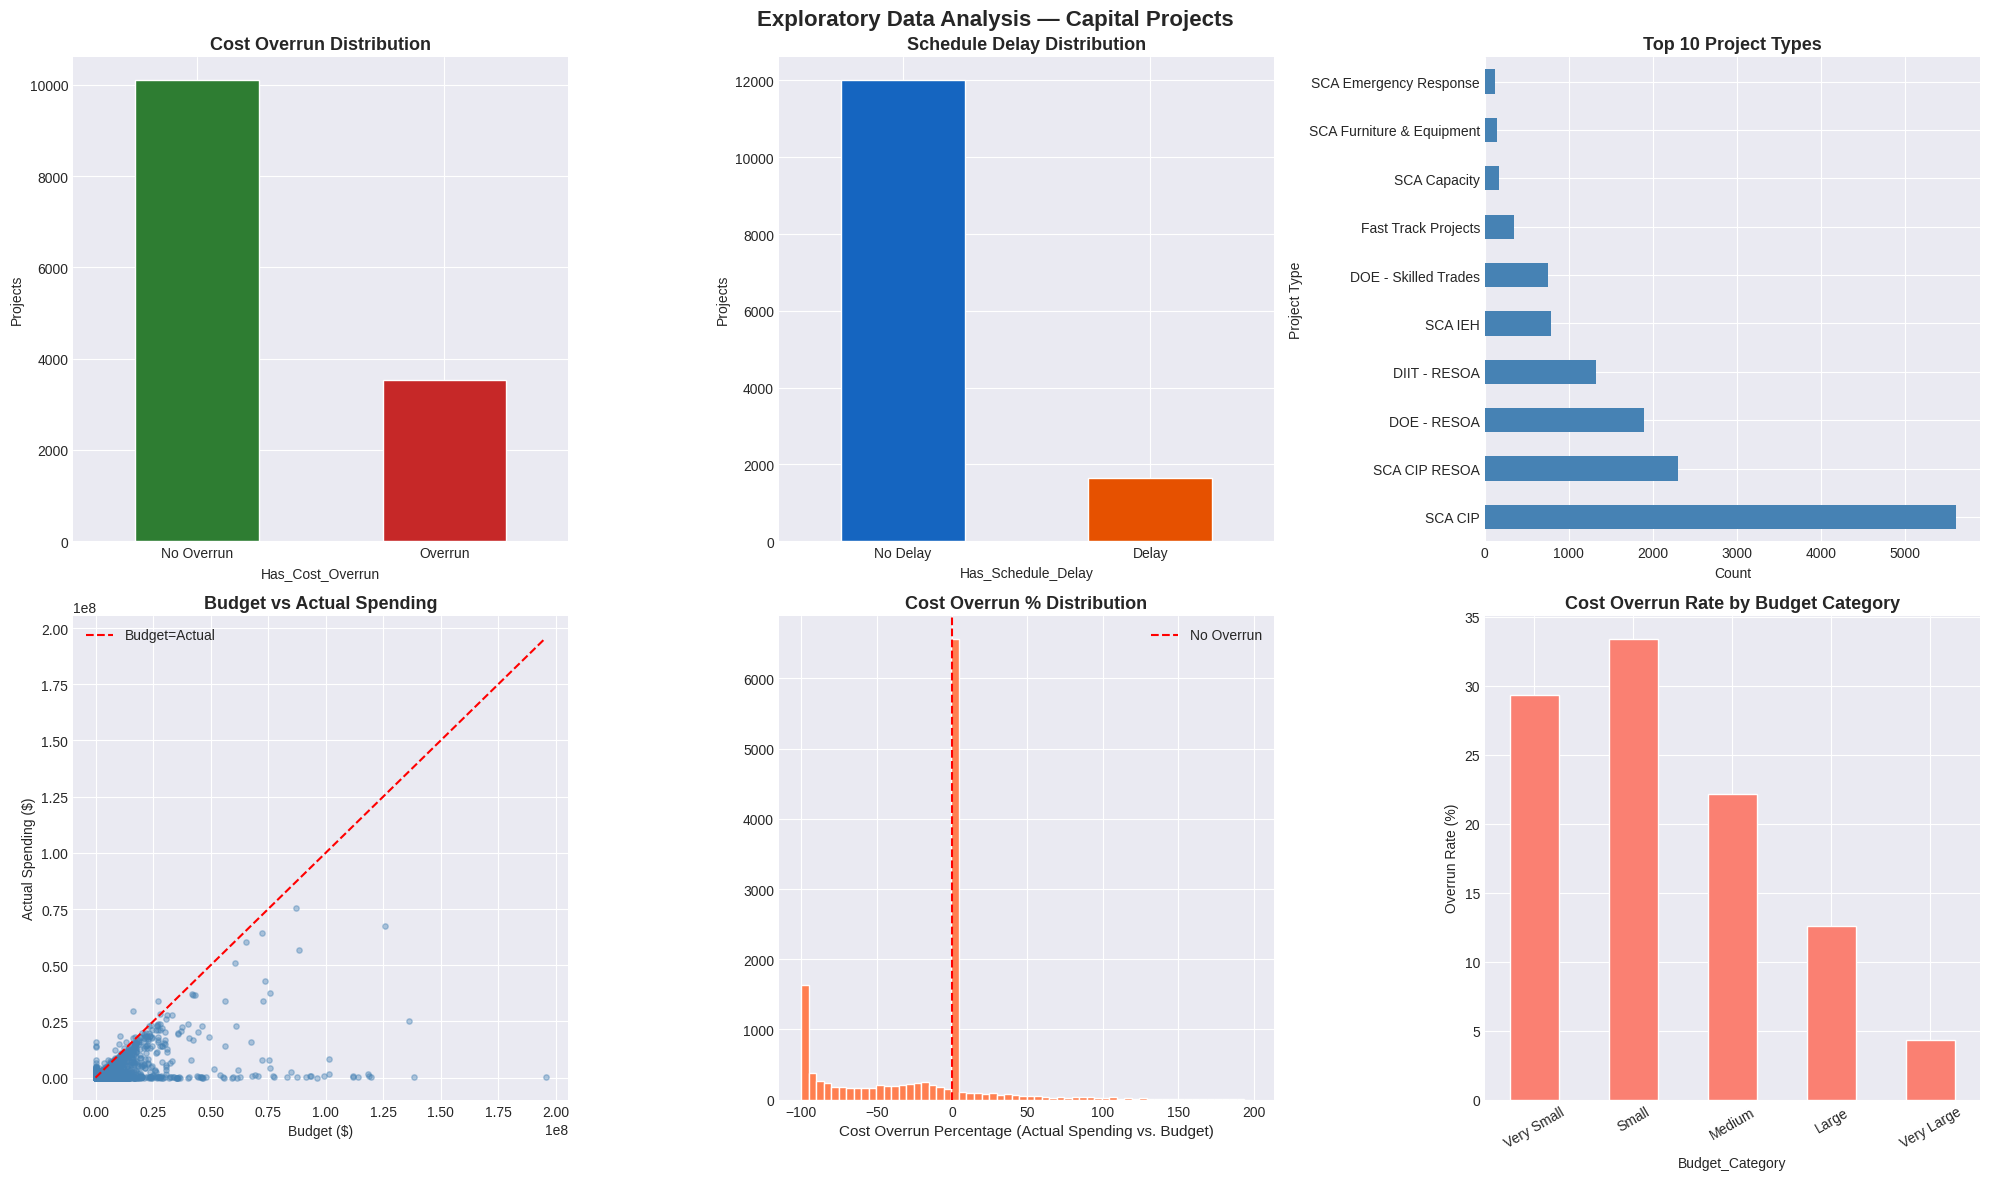

In [5]:
# CELL 1.5: EDA VISUALISATIONS
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Outcome distributions
data['Has_Cost_Overrun'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=['#2E7D32','#C62828'], edgecolor='white')
axes[0,0].set_title('Cost Overrun Distribution', fontsize=13, fontweight='bold')
axes[0,0].set_xticklabels(['No Overrun','Overrun'], rotation=0)
axes[0,0].set_ylabel('Projects')

data['Has_Schedule_Delay'].value_counts().plot(
    kind='bar', ax=axes[0,1], color=['#1565C0','#E65100'], edgecolor='white')
axes[0,1].set_title('Schedule Delay Distribution', fontsize=13, fontweight='bold')
axes[0,1].set_xticklabels(['No Delay','Delay'], rotation=0)
axes[0,1].set_ylabel('Projects')

# 2. Top project types
data['Project Type'].value_counts().head(10).plot(
    kind='barh', ax=axes[0,2], color='steelblue')
axes[0,2].set_title('Top 10 Project Types', fontsize=13, fontweight='bold')
axes[0,2].set_xlabel('Count')

# 3. Budget vs Actual Spending
vd = data.dropna(subset=['Project Budget Amount','Total Phase Actual Spending Amount'])   #validated data
axes[1,0].scatter(vd['Project Budget Amount'], vd['Total Phase Actual Spending Amount'],
                  alpha=0.4, s=15, c='steelblue')
mx = vd['Project Budget Amount'].max()
axes[1,0].plot([0,mx],[0,mx],'r--', label='Budget=Actual')
axes[1,0].set_title('Budget vs Actual Spending', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Budget ($)')
axes[1,0].set_ylabel('Actual Spending ($)')
axes[1,0].legend()

# 4. Cost overrun % distribution
cop = data['Cost_Overrun_Percentage'].replace([np.inf,-np.inf],np.nan).dropna()           #cost overrun percentage
cop = cop[(cop>=-100)&(cop<=200)]
axes[1,1].hist(cop, bins=60, color='coral', edgecolor='white')
axes[1,1].axvline(x=0, color='red', ls='--', label='No Overrun')
axes[1,1].set_title('Cost Overrun % Distribution', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Cost Overrun Percentage (Actual Spending vs. Budget)', fontsize=11)
axes[1,1].legend()

# 5. Overrun rate by budget category
budget_overrun = data.groupby('Budget_Category', observed=True)['Has_Cost_Overrun'].mean()*100
budget_overrun.plot(kind='bar', ax=axes[1,2], color='salmon', edgecolor='white')
axes[1,2].set_title('Cost Overrun Rate by Budget Category', fontsize=13, fontweight='bold')
axes[1,2].set_ylabel('Overrun Rate (%)')
axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=30)


plt.suptitle('Exploratory Data Analysis — Capital Projects', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

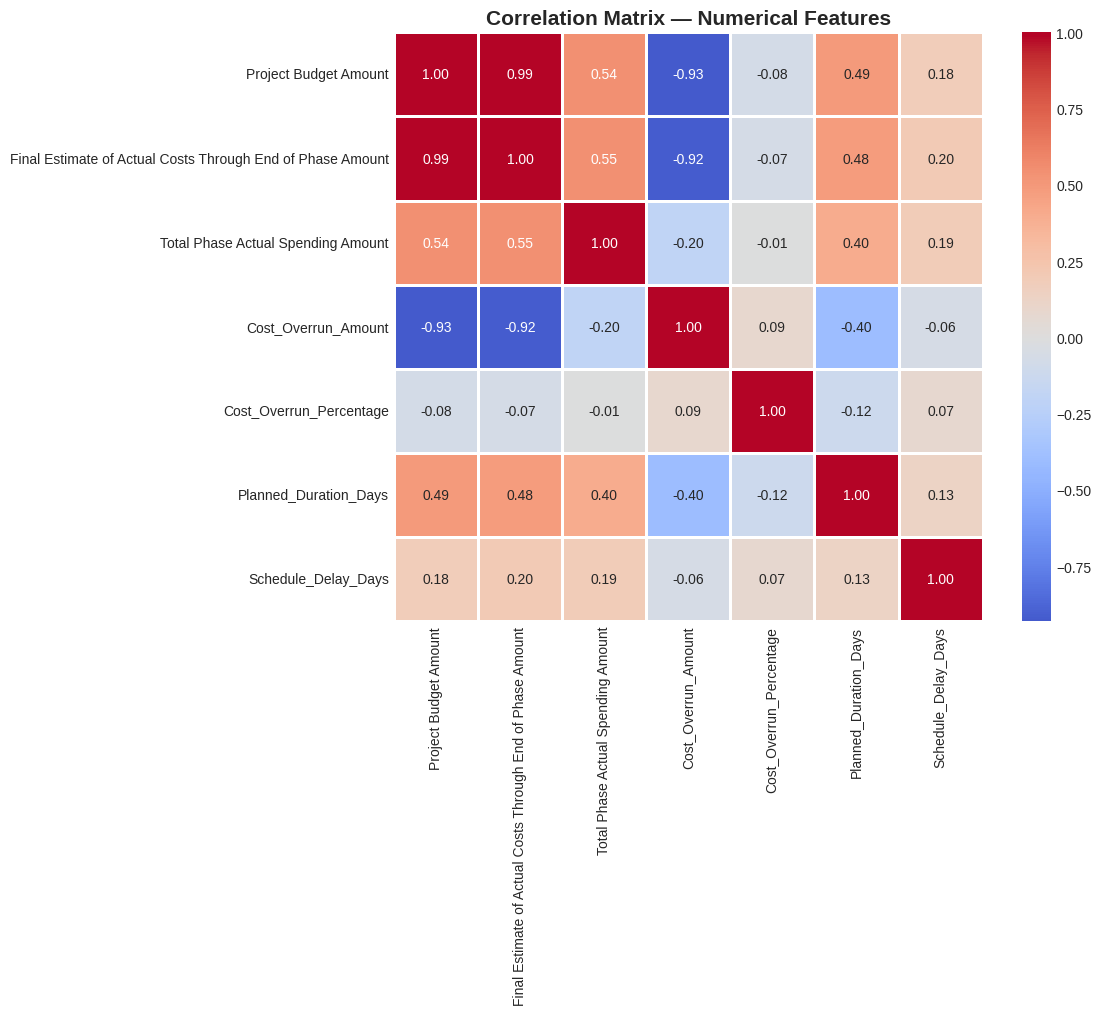

In [6]:
# CELL 1.7: CORRELATION HEATMAP
num_cols = ['Project Budget Amount',
            'Final Estimate of Actual Costs Through End of Phase Amount',
            'Total Phase Actual Spending Amount',
            'Cost_Overrun_Amount','Cost_Overrun_Percentage',
            'Planned_Duration_Days','Schedule_Delay_Days']
avail = [c for c in num_cols if c in data.columns]
corr  = data[avail].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.2f')
plt.title('Correlation Matrix — Numerical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


---
## PART 2: BENCHMARK ML MODELS — PREDICTIVE BASELINE
---

Seven standard classifiers are trained on both **Cost Overrun** and **Schedule Delay** prediction. These form the baseline that Causal Forest will be compared against.

In [7]:
# CELL 2.1: FEATURE SELECTION & PREPROCESSING
categorical_features = ['Project Type','Project Phase Name',
                         'Project Status Name','Project Geographic District']
numerical_features   = ['Project Budget Amount','Planned_Duration_Days',
                         'Start_Year','Start_Month','Start_Quarter']
feature_names        = categorical_features + numerical_features

# Build modelling datasets
cost_data     = data[categorical_features+numerical_features+['Has_Cost_Overrun']].dropna(subset=['Has_Cost_Overrun'])
schedule_data = data[categorical_features+numerical_features+['Has_Schedule_Delay']].dropna(subset=['Has_Schedule_Delay'])

def preprocess_data(df, target_col, cat_cols, num_cols):
    X = df[cat_cols+num_cols].copy()
    y = df[target_col].copy()
    X[num_cols] = SimpleImputer(strategy='median').fit_transform(X[num_cols])
    X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])
    les = {}
    for col in cat_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        les[col] = le
    return X, y, les

X_cost,     y_cost,     _ = preprocess_data(cost_data,     'Has_Cost_Overrun',   categorical_features, numerical_features)
X_schedule, y_schedule, _ = preprocess_data(schedule_data, 'Has_Schedule_Delay', categorical_features, numerical_features)

# Train / test split
X_cost_train,X_cost_test,y_cost_train,y_cost_test = train_test_split(
    X_cost,y_cost,test_size=0.2,random_state=42,stratify=y_cost)
X_sch_train,X_sch_test,y_sch_train,y_sch_test = train_test_split(
    X_schedule,y_schedule,test_size=0.2,random_state=42,stratify=y_schedule)

# Feature scaling (for distance/linear models)
sc_cost = StandardScaler()                                                       #scaled cost
Xc_tr_sc = sc_cost.fit_transform(X_cost_train)                                   #X cost train scaled
Xc_te_sc = sc_cost.transform(X_cost_test)
sc_sch   = StandardScaler()
Xs_tr_sc = sc_sch.fit_transform(X_sch_train)
Xs_te_sc = sc_sch.transform(X_sch_test)

print(f'Cost Overrun  — Train: {X_cost_train.shape}  Test: {X_cost_test.shape}')
print(f'Schedule Delay— Train: {X_sch_train.shape}  Test: {X_sch_test.shape}')


Cost Overrun  — Train: (10910, 9)  Test: (2728, 9)
Schedule Delay— Train: (10910, 9)  Test: (2728, 9)


In [8]:
# CELL 2.2: TRAIN & EVALUATE HELPER FUNCTION
def train_eval(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    yp  = model.predict(X_te)
    ypp = model.predict_proba(X_te)[:,1] if hasattr(model,'predict_proba') else None
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y_te,yp),
        'Precision': precision_score(y_te,yp,zero_division=0),
        'Recall':    recall_score(y_te,yp,zero_division=0),
        'F1-Score':  f1_score(y_te,yp,zero_division=0),
        'ROC-AUC':   roc_auc_score(y_te,ypp) if ypp is not None else None
    }, yp, ypp, model

SCALE_MODELS = ['Logistic Regression','SVM','KNN']

baseline_models = {
    'Logistic Regression': LogisticRegression(random_state=42,max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(random_state=42,max_depth=10),
    'Random Forest':       RandomForestClassifier(random_state=42,n_estimators=100),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42,n_estimators=100),
    'SVM':                 SVC(random_state=42,probability=True),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes':         GaussianNB()
}
print('Helper function and model dict ready.')


Helper function and model dict ready.


In [9]:
# CELL 2.3: COST OVERRUN — BENCHMARK TRAINING
print('='*90)
print('BENCHMARK: COST OVERRUN PREDICTION')
print('='*90)

cost_results, cost_preds, cost_trained = [], {}, {}

for name, mdl in baseline_models.items():
    import copy
    m = copy.deepcopy(mdl)
    Xtr = Xc_tr_sc if name in SCALE_MODELS else X_cost_train
    Xte = Xc_te_sc if name in SCALE_MODELS else X_cost_test
    res,yp,ypp,trained = train_eval(m, Xtr, Xte, y_cost_train, y_cost_test, name)
    cost_results.append(res)
    cost_preds[name]   = {'yp':yp,'ypp':ypp}
    cost_trained[name] = trained
    print(f'{name:<25} Acc:{res["Accuracy"]:.3f}  F1:{res["F1-Score"]:.3f}  AUC:{res["ROC-AUC"] or 0:.3f}')

cost_df = pd.DataFrame(cost_results).sort_values('F1-Score',ascending=False)
print('\nRANKED RESULTS:')
print(cost_df.to_string(index=False))


BENCHMARK: COST OVERRUN PREDICTION
Logistic Regression       Acc:0.793  F1:0.595  AUC:0.870
Decision Tree             Acc:0.886  F1:0.782  AUC:0.906
Random Forest             Acc:0.894  F1:0.792  AUC:0.945
Gradient Boosting         Acc:0.885  F1:0.771  AUC:0.947
SVM                       Acc:0.857  F1:0.712  AUC:0.910
KNN                       Acc:0.859  F1:0.717  AUC:0.895
Naive Bayes               Acc:0.356  F1:0.442  AUC:0.699

RANKED RESULTS:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
      Random Forest  0.894428   0.810651 0.774011  0.791908 0.945215
      Decision Tree  0.885997   0.776848 0.786723  0.781754 0.906269
  Gradient Boosting  0.884531   0.794603 0.748588  0.770909 0.946854
                KNN  0.858504   0.745427 0.690678  0.717009 0.895385
                SVM  0.857038   0.746894 0.679379  0.711538 0.909599
Logistic Regression  0.792522   0.603198 0.586158  0.594556 0.869772
        Naive Bayes  0.356305   0.285070 0.981638  0.441831 0.6991

In [10]:
#CELL 2.4: SCHEDULE DELAY — BENCHMARK TRAINING
print('='*90)
print('BENCHMARK: SCHEDULE DELAY PREDICTION')
print('='*90)

sch_results, sch_preds, sch_trained = [], {}, {}

for name, mdl in baseline_models.items():
    import copy
    m = copy.deepcopy(mdl)
    Xtr = Xs_tr_sc if name in SCALE_MODELS else X_sch_train
    Xte = Xs_te_sc if name in SCALE_MODELS else X_sch_test
    res,yp,ypp,trained = train_eval(m, Xtr, Xte, y_sch_train, y_sch_test, name)
    sch_results.append(res)
    sch_preds[name]   = {'yp':yp,'ypp':ypp}
    sch_trained[name] = trained
    print(f'{name:<25} Acc:{res["Accuracy"]:.3f}  F1:{res["F1-Score"]:.3f}  AUC:{res["ROC-AUC"] or 0:.3f}')

sch_df = pd.DataFrame(sch_results).sort_values('F1-Score',ascending=False)
print('\nRANKED RESULTS:')
print(sch_df.to_string(index=False))


BENCHMARK: SCHEDULE DELAY PREDICTION
Logistic Regression       Acc:0.879  F1:0.286  AUC:0.929
Decision Tree             Acc:0.936  F1:0.751  AUC:0.941
Random Forest             Acc:0.935  F1:0.731  AUC:0.973
Gradient Boosting         Acc:0.922  F1:0.695  AUC:0.966
SVM                       Acc:0.894  F1:0.513  AUC:0.940
KNN                       Acc:0.916  F1:0.639  AUC:0.928
Naive Bayes               Acc:0.880  F1:0.000  AUC:0.797

RANKED RESULTS:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
      Decision Tree  0.936217   0.706199 0.801223  0.750716 0.940871
      Random Forest  0.934751   0.722388 0.740061  0.731118 0.973355
  Gradient Boosting  0.921921   0.653226 0.743119  0.695279 0.965809
                KNN  0.915689   0.655949 0.623853  0.639498 0.928392
                SVM  0.893695   0.568773 0.467890  0.513423 0.940212
Logistic Regression  0.879399   0.492537 0.201835  0.286334 0.928576
        Naive Bayes  0.880132   0.000000 0.000000  0.000000 0.79

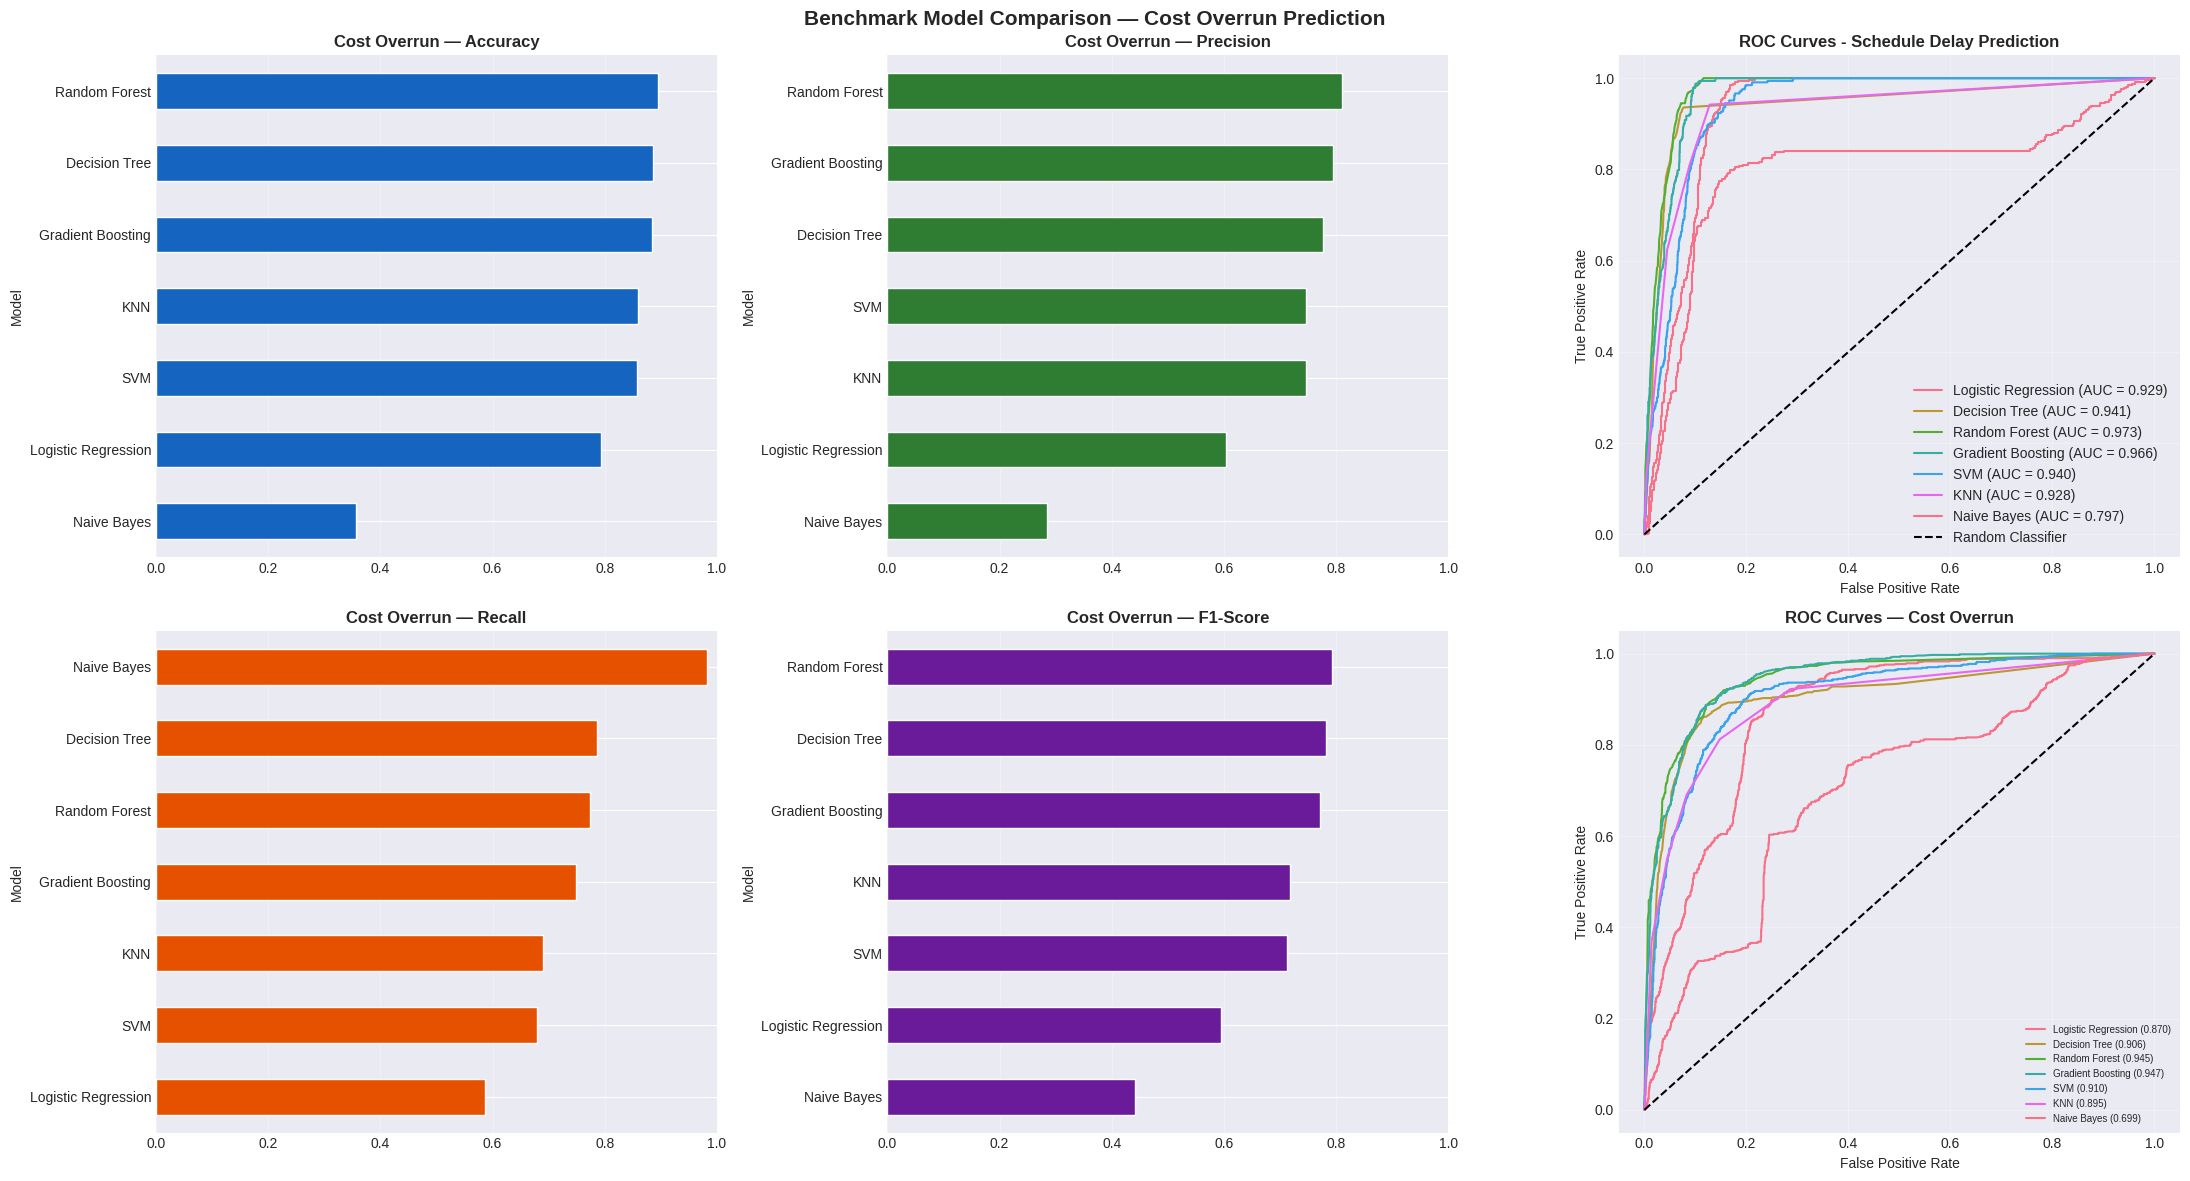

In [11]:
#CELL 2.5: BENCHMARK VISUALISATION
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

metrics = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
colors  = ['#1565C0','#2E7D32','#E65100','#6A1B9A','#C62828']

for i, (met, col) in enumerate(zip(metrics[:4], colors)):
    row, c = i//2, i%2
    cost_df.sort_values(met,ascending=True).plot(
        x='Model', y=met, kind='barh', ax=axes[row,c],
        color=col, legend=False, edgecolor='white')
    axes[row,c].set_title(f'Cost Overrun — {met}', fontsize=12, fontweight='bold')
    axes[row,c].set_xlim(0,1)
    axes[row,c].grid(axis='x',alpha=0.3)

# ROC Curve for Schedule Delay
for name in sch_preds.keys():
    if sch_preds[name]['ypp'] is not None:
        fpr, tpr, _ = roc_curve(y_sch_test, sch_preds[name]['ypp'])
        auc = roc_auc_score(y_sch_test, sch_preds[name]['ypp'])
        axes[0,2].plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

axes[0,2].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0,2].set_xlabel('False Positive Rate')
axes[0,2].set_ylabel('True Positive Rate')
axes[0,2].set_title('ROC Curves - Schedule Delay Prediction', fontsize=12, fontweight='bold')
axes[0,2].legend(loc='lower right')
axes[0,2].grid(True, alpha=0.3)

# ROC curves — Cost Overrun
for name in cost_preds:
    if cost_preds[name]['ypp'] is not None:
        fpr,tpr,_ = roc_curve(y_cost_test, cost_preds[name]['ypp'])
        auc = roc_auc_score(y_cost_test, cost_preds[name]['ypp'])
        axes[1,2].plot(fpr,tpr,label=f'{name} ({auc:.3f})')
axes[1,2].plot([0,1],[0,1],'k--')
axes[1,2].set_title('ROC Curves — Cost Overrun', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('False Positive Rate'); axes[1,2].set_ylabel('True Positive Rate')
axes[1,2].legend(fontsize=7, loc='lower right'); axes[1,2].grid(alpha=0.3)

plt.suptitle('Benchmark Model Comparison — Cost Overrun Prediction',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Best Cost Model:     Random Forest
Best Schedule Model: Decision Tree


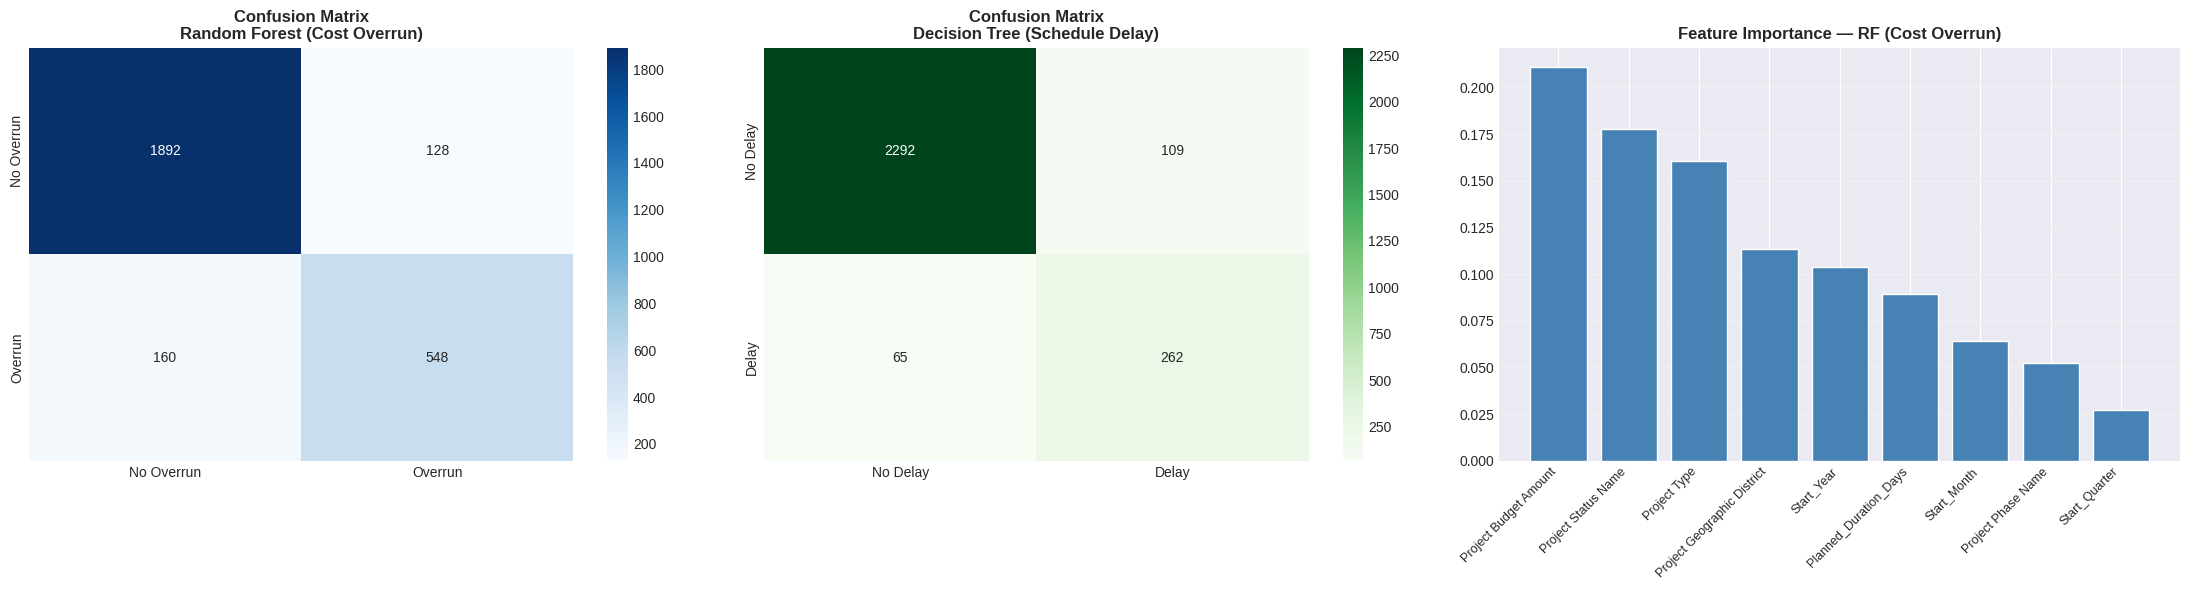


CLASSIFICATION REPORT — Best Cost Model:
              precision    recall  f1-score   support

  No Overrun       0.92      0.94      0.93      2020
     Overrun       0.81      0.77      0.79       708

    accuracy                           0.89      2728
   macro avg       0.87      0.86      0.86      2728
weighted avg       0.89      0.89      0.89      2728



In [12]:
#CELL 2.6: CONFUSION MATRICES & FEATURE IMPORTANCE
best_cost_name = cost_df.iloc[0]['Model']        #First row
best_sch_name  = sch_df.iloc[0]['Model']
print(f'Best Cost Model:     {best_cost_name}')
print(f'Best Schedule Model: {best_sch_name}')

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Confusion matrix — cost
cm_c = confusion_matrix(y_cost_test, cost_preds[best_cost_name]['yp'])
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Overrun','Overrun'],
            yticklabels=['No Overrun','Overrun'])
axes[0].set_title(f'Confusion Matrix\n{best_cost_name} (Cost Overrun)', fontsize=12, fontweight='bold')

# Confusion matrix — schedule
cm_s = confusion_matrix(y_sch_test, sch_preds[best_sch_name]['yp'])
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Delay','Delay'],
            yticklabels=['No Delay','Delay'])
axes[1].set_title(f'Confusion Matrix\n{best_sch_name} (Schedule Delay)', fontsize=12, fontweight='bold')

# Feature importance — Random Forest
rf_m = cost_trained.get('Random Forest')
if rf_m and hasattr(rf_m,'feature_importances_'):
    imp  = rf_m.feature_importances_
    idx  = np.argsort(imp)[::-1]
    axes[2].bar(range(len(imp)), imp[idx], color='steelblue', edgecolor='white')
    axes[2].set_xticks(range(len(imp)))
    axes[2].set_xticklabels([feature_names[i] for i in idx], rotation=45, ha='right', fontsize=9)
    axes[2].set_title('Feature Importance — RF (Cost Overrun)', fontsize=12, fontweight='bold')
    axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nCLASSIFICATION REPORT — Best Cost Model:')
print(classification_report(y_cost_test, cost_preds[best_cost_name]['yp'],
      target_names=['No Overrun','Overrun']))


---
## PART 3: ENHANCED RANDOM FOREST — HYPERPARAMETER TUNING & ADVANCED ENSEMBLES
---

In [13]:
#CELL 3.1: HYPERPARAMETER TUNING — RANDOM FOREST
print('='*90)
print('ENHANCED RANDOM FOREST — GRIDSEARCHCV')
print('='*90)

param_grid_rf = {
    'n_estimators':     [100,200,300],
    'max_depth':        [10,15,20,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_features':     ['sqrt','log2'],
    'bootstrap':        [True,False]
}
print(f'Grid size: {3*4*3*3*2*2} combinations × 5 folds = {3*4*3*3*2*2*5} fits\n')

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
rf_grid.fit(X_cost_train, y_cost_train)

print('\nBEST PARAMETERS:')
for k,v in rf_grid.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV F1-Score: {rf_grid.best_score_:.4f}')

best_rf = rf_grid.best_estimator_
y_rf_pred  = best_rf.predict(X_cost_test)
y_rf_proba = best_rf.predict_proba(X_cost_test)[:,1]

baseline_f1  = cost_df[cost_df['Model']=='Random Forest'].iloc[0]['F1-Score']
baseline_acc = cost_df[cost_df['Model']=='Random Forest'].iloc[0]['Accuracy']
print('\nOPTIMIZED RF — TEST SET PERFORMANCE:')
print(f'  Accuracy:  {accuracy_score(y_cost_test,y_rf_pred):.4f}  ({accuracy_score(y_cost_test,y_rf_pred)-baseline_acc:+.4f} vs baseline)')
print(f'  Precision: {precision_score(y_cost_test,y_rf_pred):.4f}')
print(f'  Recall:    {recall_score(y_cost_test,y_rf_pred):.4f}')
print(f'  F1-Score:  {f1_score(y_cost_test,y_rf_pred):.4f}  ({f1_score(y_cost_test,y_rf_pred)-baseline_f1:+.4f} vs baseline)')
print(f'  ROC-AUC:   {roc_auc_score(y_cost_test,y_rf_proba):.4f}')


ENHANCED RANDOM FOREST — GRIDSEARCHCV
Grid size: 432 combinations × 5 folds = 2160 fits

Fitting 5 folds for each of 432 candidates, totalling 2160 fits

BEST PARAMETERS:
  bootstrap: True
  max_depth: 20
  max_features: sqrt
  min_samples_leaf: 2
  min_samples_split: 10
  n_estimators: 300

Best CV F1-Score: 0.8124

OPTIMIZED RF — TEST SET PERFORMANCE:
  Accuracy:  0.8977  (+0.0033 vs baseline)
  Precision: 0.8150
  Recall:    0.7839
  F1-Score:  0.7991  (+0.0072 vs baseline)
  ROC-AUC:   0.9509


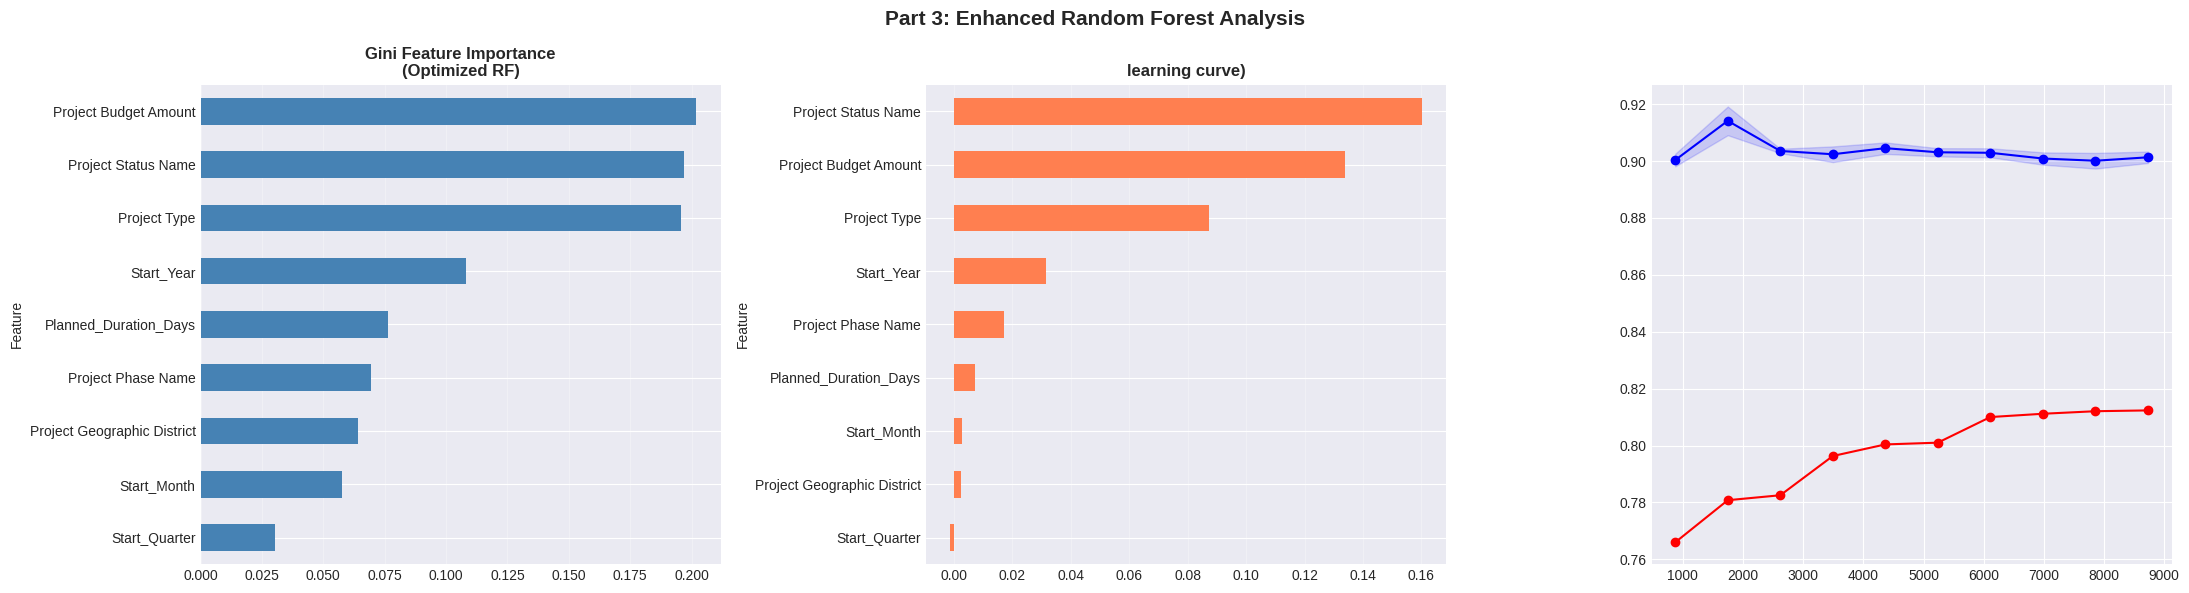

In [14]:
# CELL 3.2: FEATURE IMPORTANCE & LEARNING CURVE
# Gini importance
imp     = best_rf.feature_importances_
idx     = np.argsort(imp)[::-1]
imp_df  = pd.DataFrame({'Feature':[feature_names[i] for i in idx],'Gini_Importance':imp[idx]})

# Permutation importance
perm = permutation_importance(best_rf,X_cost_test,y_cost_test,n_repeats=10,random_state=42,n_jobs=-1)
perm_df = pd.DataFrame({
    'Feature':feature_names,
    'Perm_Importance':perm.importances_mean,
    'Perm_Std':perm.importances_std
}).sort_values('Perm_Importance',ascending=False)

# Learning curve
tr_sz,tr_sc,va_sc = learning_curve(
    best_rf,X_cost_train,y_cost_train,cv=5,n_jobs=-1,
    train_sizes=np.linspace(0.1,1.0,10),scoring='f1')

fig, axes = plt.subplots(1, 3, figsize=(22,6))

# Gini
imp_df.head(9).plot(x='Feature',y='Gini_Importance',kind='barh',ax=axes[0],
                    color='steelblue',legend=False)
axes[0].set_title('Gini Feature Importance\n(Optimized RF)',fontsize=12,fontweight='bold')
axes[0].invert_yaxis(); axes[0].grid(axis='x',alpha=0.3)

# Permutation
perm_df.head(9).plot(x='Feature',y='Perm_Importance',kind='barh',ax=axes[1],
                     color='coral',legend=False)
axes[1].set_title('Permutation Importance\n(Optimized RF)',fontsize=12,fontweight='bold')
axes[1].invert_yaxis(); axes[1].grid(axis='x',alpha=0.3)

# Learning curve
tm,ts = tr_sc.mean(1),tr_sc.std(1)                                               #Training mean,Training standard deviation
vm,vs = va_sc.mean(1),va_sc.std(1)                                               #validated mean
axes[2].plot(tr_sz,tm,'b-o',label='Train')
axes[2].fill_between(tr_sz,tm-ts,tm+ts,alpha=0.15,color='blue')
axes[2].plot(tr_sz,vm,'r-o',label='Validation')
axes[1].set_title('learning curve)',fontsize=12,fontweight='bold')
plt.suptitle('Part 3: Enhanced Random Forest Analysis',fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()


ADVANCED ENSEMBLE METHODS
RF (Optimized)       F1:0.7991  AUC:0.9509
ExtraTrees           F1:0.7757  AUC:0.9440
AdaBoost             F1:0.7276  AUC:0.9273
Bagging              F1:0.7917  AUC:0.9420
Voting (Soft)        F1:0.7904  AUC:0.9510


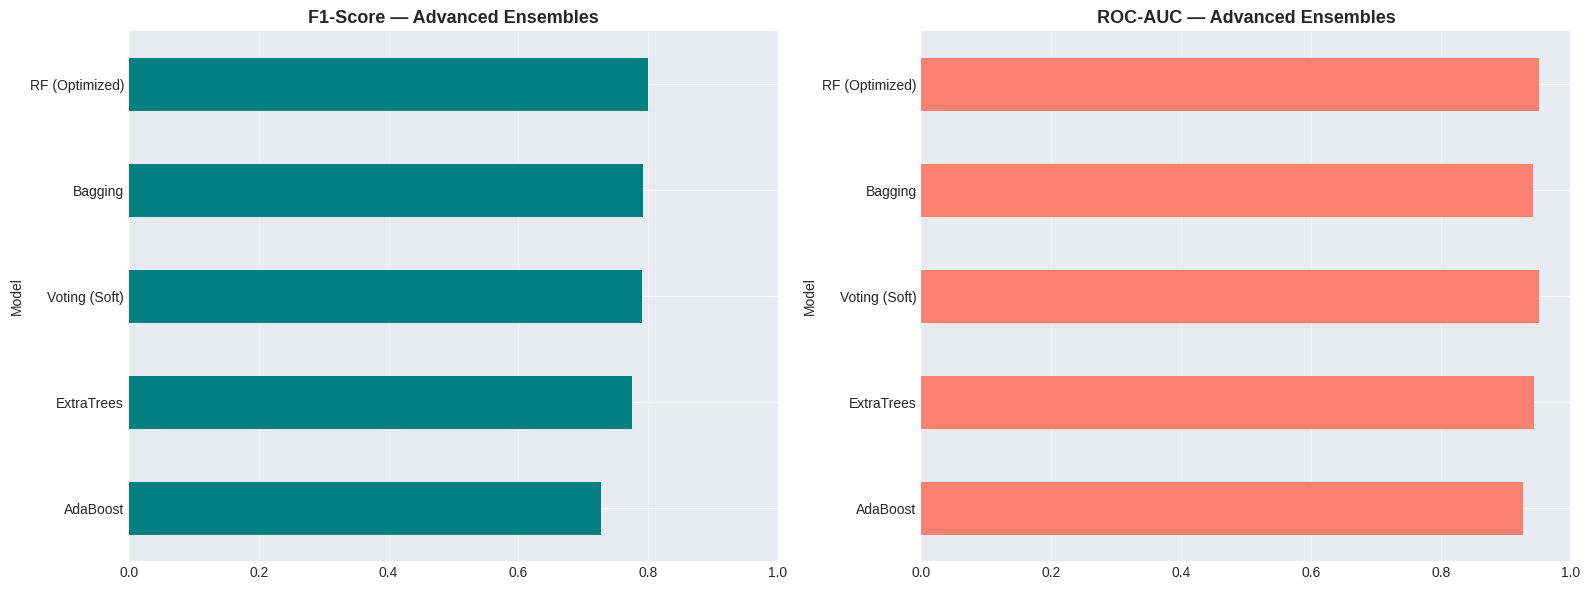

         Model  Accuracy  F1-Score  ROC-AUC
RF (Optimized)  0.897727  0.799136 0.950881
       Bagging  0.893695  0.791667 0.941988
 Voting (Soft)  0.894428  0.790393 0.951034
    ExtraTrees  0.887830  0.775660 0.944026
      AdaBoost  0.869868  0.727552 0.927279


In [15]:
# CELL 3.3: ADVANCED ENSEMBLE COMPARISON
print('='*90)
print('ADVANCED ENSEMBLE METHODS')
print('='*90)

adv_ensembles = {
    'RF (Optimized)': best_rf,
    'ExtraTrees':     ExtraTreesClassifier(n_estimators=200,random_state=42,max_depth=20),
    'AdaBoost':       AdaBoostClassifier(n_estimators=100,random_state=42),
    'Bagging':        BaggingClassifier(n_estimators=100,random_state=42),
    'Voting (Soft)':  VotingClassifier(
        estimators=[
            ('rf',RandomForestClassifier(n_estimators=100,random_state=42)),
            ('gb',GradientBoostingClassifier(n_estimators=100,random_state=42)),
            ('et',ExtraTreesClassifier(n_estimators=100,random_state=42))
        ], voting='soft'
    )
}

ens_results = []
for name, m in adv_ensembles.items():
    if name != 'RF (Optimized)':
        m.fit(X_cost_train, y_cost_train)
        yp  = m.predict(X_cost_test)
        ypp = m.predict_proba(X_cost_test)[:,1]
    else:
        yp,ypp = y_rf_pred, y_rf_proba
    ens_results.append({
        'Model':name,
        'Accuracy':accuracy_score(y_cost_test,yp),
        'F1-Score':f1_score(y_cost_test,yp),
        'ROC-AUC':roc_auc_score(y_cost_test,ypp)
    })
    print(f'{name:<20} F1:{f1_score(y_cost_test,yp):.4f}  AUC:{roc_auc_score(y_cost_test,ypp):.4f}')

ens_df = pd.DataFrame(ens_results).sort_values('F1-Score',ascending=False)

fig, axes = plt.subplots(1,2,figsize=(16,6))
ens_df.plot(x='Model',y='F1-Score', kind='barh',ax=axes[0],color='teal',legend=False)
ens_df.plot(x='Model',y='ROC-AUC',  kind='barh',ax=axes[1],color='salmon',legend=False)
for ax, title in zip(axes,['F1-Score','ROC-AUC']):
    ax.set_title(f'{title} — Advanced Ensembles',fontsize=13,fontweight='bold')
    ax.set_xlim(0,1); ax.invert_yaxis(); ax.grid(axis='x',alpha=0.3)
plt.tight_layout()
plt.show()
print(ens_df.to_string(index=False))


---
## PART 4: CAUSAL AI — CAUSAL FOREST DML (EconML + DoWhy)
---

### The Predictive → Prescriptive Bridge

| Question | Predictive ML (Parts 1-3) | Causal AI (Part 4) |
|----------|--------------------------|--------------------|
| What will happen? | ✅ Yes — gives probability score | Partial |
| **Why** does it happen? | ❌ No | ✅ **Yes — causal effect estimates** |
| What should we **do**? | ❌ No | ✅ **Yes — CATE-driven policy rules** |

### Framework
- **Treatment (T)**: `is_SCA_managed` — SCA (1) vs DOE (0) project delivery
- **Outcome (Y)**: `Has_Cost_Overrun`
- **Covariates (X)**: District, Budget, Duration, Phase, Year, Quarter
- **Method**: CausalForestDML (Double ML) — residualizes Y and T on confounders, then fits honest causal forest on residuals to estimate CATE(x)

CATE(x) = E[Y(1) - Y(0) | X = x]

In [16]:
#  CELL 4.1: BUILD CAUSAL ANALYSIS DATASEt
data['is_SCA_managed'] = data['Project Type'].apply(
    lambda x: 1 if 'SCA' in str(x) else 0                                        # Treatment: SCA-managed (1) vs DOE-managed (0)
)
# Cost overrun pct (clean version)
data['Cost_Overrun_Pct'] = (
    data['Cost_Overrun_Amount'] / data['Project Budget Amount'] * 100
).replace([np.inf,-np.inf], np.nan)

# Phase encoding
phase_map = {'Scope':0,'Design':1,'Construction':2,'F&E':3,'Procurement':4,'Closeout':5}
data['Phase_Encoded'] = data['Project Phase Name'].map(phase_map).fillna(2)

# Causal feature set
causal_features = ['Project Geographic District','Project Budget Amount',
                   'Planned_Duration_Days','Start_Year','Start_Quarter','Phase_Encoded']

df_causal = data[
    causal_features + ['is_SCA_managed','Has_Cost_Overrun','Cost_Overrun_Pct',
                       'Has_Schedule_Delay','Project Type','Project Phase Name']
].copy()

# Keep complete records; budget > 0
df_causal = df_causal.dropna(subset=['Project Budget Amount','Has_Cost_Overrun'])
df_causal = df_causal[df_causal['Project Budget Amount'] > 0]

#  Impute remaining NaN
for col in causal_features:
    if df_causal[col].isna().any():
        df_causal[col] = df_causal[col].fillna(df_causal[col].median())

# Cap extreme budget outliers & log-transform
q99 = df_causal['Project Budget Amount'].quantile(0.99)
df_causal['Project Budget Amount'] = df_causal['Project Budget Amount'].clip(upper=q99)
df_causal['Log_Budget'] = np.log1p(df_causal['Project Budget Amount'])

causal_features_model = [f for f in causal_features if f!='Project Budget Amount'] + ['Log_Budget']

print(f'Causal dataset: {df_causal.shape}')
vc = df_causal['is_SCA_managed'].value_counts()
print(f'  SCA-managed (T=1): {vc.get(1,0):,}  ({vc.get(1,0)/len(df_causal)*100:.1f}%)')
print(f'  DOE-managed (T=0): {vc.get(0,0):,}  ({vc.get(0,0)/len(df_causal)*100:.1f}%)')
print(f'\nOutcome rates:')
print(f'  SCA overrun rate: {df_causal[df_causal["is_SCA_managed"]==1]["Has_Cost_Overrun"].mean()*100:.1f}%')
print(f'  DOE overrun rate: {df_causal[df_causal["is_SCA_managed"]==0]["Has_Cost_Overrun"].mean()*100:.1f}%')
naive_ate = (df_causal[df_causal['is_SCA_managed']==1]['Has_Cost_Overrun'].mean()
           - df_causal[df_causal['is_SCA_managed']==0]['Has_Cost_Overrun'].mean())
print(f'  Naive ATE (confounded): {naive_ate:+.4f} <- Causal Forest will adjust this')

Causal dataset: (7350, 13)
  SCA-managed (T=1): 7,326  (99.7%)
  DOE-managed (T=0): 24  (0.3%)

Outcome rates:
  SCA overrun rate: 21.6%
  DOE overrun rate: 20.8%
  Naive ATE (confounded): +0.0082 <- Causal Forest will adjust this


In [17]:
# CELL 4.2: DOWHY CAUSAL GRAPH & IDENTIFICATION
# Formiables confound treatment & outcome.
# DoWhy uses the DAG + backdoor criterion to prove identifiability.

if DOWHY_AVAILABLE:
    df_dw = df_causal[['is_SCA_managed','Has_Cost_Overrun',
                        'Project Geographic District','Log_Budget',
                        'Phase_Encoded','Start_Year']].dropna().reset_index(drop=True)
    df_dw = df_dw.rename(columns={'Project Geographic District':'District'})

    causal_graph = '''
    digraph {
        District -> is_SCA_managed;
        District -> Has_Cost_Overrun;
        Log_Budget -> is_SCA_managed;
        Log_Budget -> Has_Cost_Overrun;
        Phase_Encoded -> is_SCA_managed;
        Phase_Encoded -> Has_Cost_Overrun;
        Start_Year -> is_SCA_managed;
        Start_Year -> Has_Cost_Overrun;
        is_SCA_managed -> Has_Cost_Overrun;
    }'''

    dw_model = CausalModel(
        data=df_dw, treatment='is_SCA_managed',
        outcome='Has_Cost_Overrun', graph=causal_graph
    )
    identified = dw_model.identify_effect(proceed_when_unidentifiable=True)
    print('=== CAUSAL IDENTIFICATION ===')
    print(identified)

    # ATE estimate — linear regression (backdoor)
    est_lr = dw_model.estimate_effect(                                          #Estimate using Linear Regression
        identified, method_name='backdoor.linear_regression', target_units='ate')
    print(f'\n=== ATE (Linear Regression Backdoor) ===')
    print(f'ATE = {est_lr.value:.4f}')
    d = 'INCREASES' if est_lr.value>0 else 'DECREASES'                          #Direction
    print(f'SCA management {d} cost overrun prob by {abs(est_lr.value)*100:.1f} pp')

    # Refutation tests
    for ref_name, ref_kwargs in [
        ('Placebo Treatment',   {'method_name':'placebo_treatment_refuter','placebo_type':'permute','num_simulations':100}),
        ('Random Common Cause', {'method_name':'random_common_cause','num_simulations':100}),
        ('Data Subset',         {'method_name':'data_subset_refuter','subset_fraction':0.8,'num_simulations':20})
    ]:
        try:
            ref = dw_model.refute_estimate(identified, est_lr, **ref_kwargs)
            print(f'\n=== REFUTATION: {ref_name} ===')
            print(ref)
        except Exception as e:
            print(f'\n{ref_name}: {e}')
else:
    print('DoWhy not available — install with: pip install dowhy')
    print('Proceeding to EconML Causal Forest.')


ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...


=== CAUSAL IDENTIFICATION ===
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                      ↪
─────────────────(E[Has_Cost_Overrun|Phase_Encoded,District,Start_Year,Log_Bud ↪
d[is_SCA_managed]                                                              ↪

↪      
↪ get])
↪      
Estimand assumption 1, Unconfoundedness: If U→{is_SCA_managed} and U→Has_Cost_Overrun then P(Has_Cost_Overrun|is_SCA_managed,Phase_Encoded,District,Start_Year,Log_Budget,U) = P(Has_Cost_Overrun|is_SCA_managed,Phase_Encoded,District,Start_Year,Log_Budget)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
        d                                                                      ↪
─────────────────(E[Has_Cost_Overrun|Phase_Encoded,

             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.



=== REFUTATION: Data Subset ===
Refute: Use a subset of data
Estimated effect:0.054007954619455456
New effect:0.036314442372777936
p value:0.3566273431616287



In [18]:
# CELL 4.3: ECONML — CAUSAL FOREST DML
# Double ML removes confounding via cross-fitting:
#   Step 1: Y resid = Y - E[Y|W]   (outcome nuisance model)
#   Step 2: T resid = T - E[T|W]   (treatment nuisance model)
#   Step 3: Causal Forest regresses Y resid on T resid * X -> CATE(x)

if ECONML_AVAILABLE:
    X_cate = df_causal[causal_features_model].values
    T_cate = df_causal['is_SCA_managed'].values
    Y_cate = df_causal['Has_Cost_Overrun'].values.astype(float)

    X_tr_cf,X_te_cf,T_tr_cf,T_te_cf,Y_tr_cf,Y_te_cf = train_test_split(
        X_cate,T_cate,Y_cate,test_size=0.3,random_state=42,stratify=T_cate)

    print('='*70)
    print('FITTING CAUSAL FOREST DML')
    print(f'Train: {X_tr_cf.shape[0]:,}  |  Test: {X_te_cf.shape[0]:,}  |  Features: {X_tr_cf.shape[1]}')
    print('Y-model: RandomForestClassifier(100 trees)')
    print('T-model: RandomForestClassifier(100 trees)')
    print('CATE:    CausalForest(500 trees, honest, subsampled)')
    print('='*70)

    cf_model = CausalForestDML(
        model_y=RandomForestRegressor(n_estimators=100,max_depth=8,random_state=42,n_jobs=-1),
        model_t=RandomForestRegressor(n_estimators=100,max_depth=8,random_state=42,n_jobs=-1),
        n_estimators=500, min_samples_leaf=10, max_depth=6,
        max_samples=0.5, inference=True, random_state=42, n_jobs=-1
    )
    cf_model.fit(Y_tr_cf, T_tr_cf, X=X_tr_cf, W=None)
    print('\nCausal Forest DML fitted successfully!')

    # CATE predictions
    cate_pred  = cf_model.effect(X_te_cf)                                        # Prediction
    cate_ci    = cf_model.effect_interval(X_te_cf, alpha=0.05)                   # Confidence Interval
    cate_lower, cate_upper = cate_ci
    ate        = cf_model.ate(X_te_cf)
    ate_ci     = cf_model.ate_interval(X_te_cf, alpha=0.05)

    print('\n=== CAUSAL FOREST RESULTS ===')
    print(f'ATE = {ate:+.4f}  95% CI: [{ate_ci[0]:.4f}, {ate_ci[1]:.4f}]')
    d = 'INCREASES' if ate>0 else 'DECREASES'
    print(f'SCA management {d} cost overrun probability by {abs(ate)*100:.1f} pp')
    print(f'\nCATEs across {len(cate_pred):,} test projects:')
    print(f'  Mean: {np.mean(cate_pred):+.4f} | Median: {np.median(cate_pred):+.4f} | Std: {np.std(cate_pred):.4f}')
    print(f'  Range: [{np.min(cate_pred):.4f}, {np.max(cate_pred):.4f}]')
    n_ben = (cate_pred<0).sum()                                                  # Number of Beneficiaries
    print(f'  Projects benefiting from SCA (CATE<0): {n_ben:,} ({n_ben/len(cate_pred)*100:.1f}%)')
    print(f'  KEY FINDING: Effect is HETEROGENEOUS — SCA helps some, hurts others')
else:
    print('EconML not available.')
    ate = -0.05  # fallback for Part 5


FITTING CAUSAL FOREST DML
Train: 5,145  |  Test: 2,205  |  Features: 6
Y-model: RandomForestClassifier(100 trees)
T-model: RandomForestClassifier(100 trees)
CATE:    CausalForest(500 trees, honest, subsampled)

Causal Forest DML fitted successfully!

=== CAUSAL FOREST RESULTS ===
ATE = +0.0099  95% CI: [-0.6478, 0.6677]
SCA management INCREASES cost overrun probability by 1.0 pp

CATEs across 2,205 test projects:
  Mean: +0.0099 | Median: -0.0450 | Std: 0.2233
  Range: [-0.7027, 0.9892]
  Projects benefiting from SCA (CATE<0): 1,493 (67.7%)
  KEY FINDING: Effect is HETEROGENEOUS — SCA helps some, hurts others


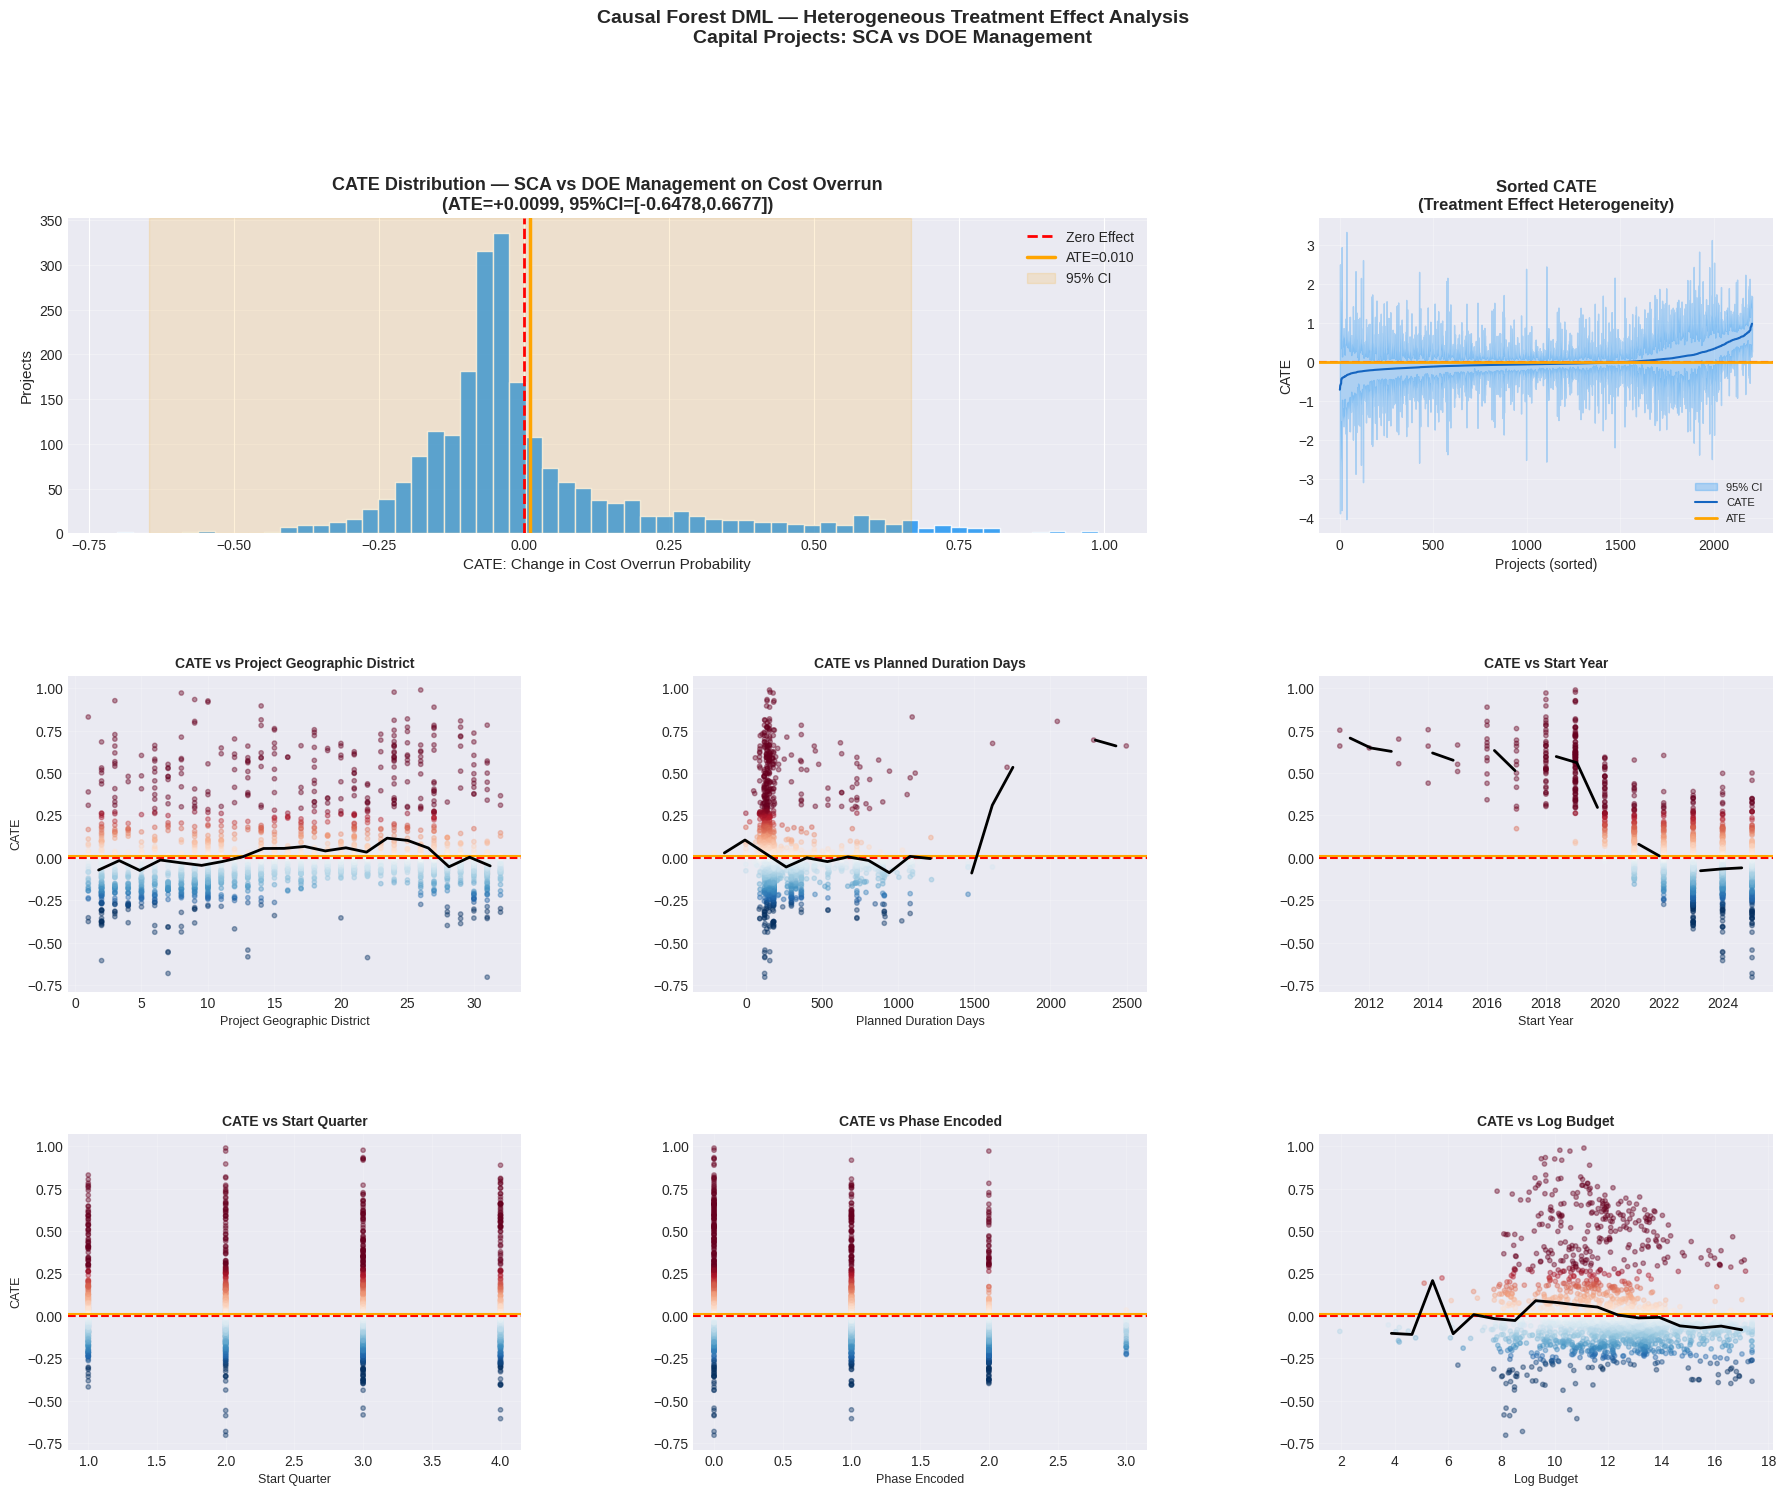

In [19]:
# CELL 4.4: CATE VISUALISATIONS
if ECONML_AVAILABLE:
    fig = plt.figure(figsize=(22, 16))
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

    # 1. CATE histogram
    ax1 = fig.add_subplot(gs[0,:2])
    ax1.hist(cate_pred, bins=60, color='#2196F3', edgecolor='white', alpha=0.85)
    ax1.axvline(x=0, color='red', ls='--', lw=2, label='Zero Effect')
    ax1.axvline(x=ate, color='orange', ls='-', lw=2.5, label=f'ATE={ate:.3f}')
    ax1.axvspan(ate_ci[0], ate_ci[1], alpha=0.15, color='orange', label='95% CI')
    ax1.set_title('CATE Distribution — SCA vs DOE Management on Cost Overrun\n'
                  f'(ATE={ate:+.4f}, 95%CI=[{ate_ci[0]:.4f},{ate_ci[1]:.4f}])',
                  fontsize=13, fontweight='bold')
    ax1.set_xlabel('CATE: Change in Cost Overrun Probability', fontsize=11)
    ax1.set_ylabel('Projects', fontsize=11)
    ax1.legend(fontsize=10); ax1.grid(axis='y', alpha=0.3)

    # 2. Sorted CATE (heterogeneity plot)
    ax2 = fig.add_subplot(gs[0,2])
    si   = np.argsort(cate_pred)
    xp   = np.arange(len(cate_pred))
    ax2.fill_between(xp, cate_lower[si], cate_upper[si], alpha=0.3, color='#2196F3', label='95% CI')
    ax2.plot(xp, cate_pred[si], color='#1565C0', lw=1.5, label='CATE')
    ax2.axhline(y=0, color='red', ls='--', lw=1.5)
    ax2.axhline(y=ate, color='orange', ls='-', lw=2, label='ATE')
    ax2.set_title('Sorted CATE\n(Treatment Effect Heterogeneity)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Projects (sorted)'); ax2.set_ylabel('CATE')
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

    # 3-8. CATE vs each feature
    from scipy.stats import binned_statistic
    for i_f, feat in enumerate(causal_features_model[:6]):
        row = (i_f//3)+1; col = i_f%3
        ax  = fig.add_subplot(gs[row,col])
        fv  = X_te_cf[:, causal_features_model.index(feat)]                     #feature values
        sc  = ax.scatter(fv, cate_pred, c=cate_pred, cmap='RdBu_r',
                         alpha=0.4, s=10, vmin=-0.3, vmax=0.3)
        ax.axhline(y=0,   color='red',    ls='--', lw=1.5)
        ax.axhline(y=ate, color='orange', ls='-',  lw=1.5)
        try:
            bm,be,_ = binned_statistic(fv,cate_pred,statistic='mean',bins=20)   #bin mean,bin edges
            bc = (be[:-1]+be[1:])/2                                             #bin centers
            ax.plot(bc,bm,'k-',lw=2)
        except: pass
        ax.set_title(f'CATE vs {feat.replace("_"," ")}', fontsize=10, fontweight='bold')
        ax.set_xlabel(feat.replace('_',' '), fontsize=9)
        if col==0: ax.set_ylabel('CATE', fontsize=9)
        ax.grid(alpha=0.2)

    plt.suptitle('Causal Forest DML — Heterogeneous Treatment Effect Analysis\n'
                 'Capital Projects: SCA vs DOE Management',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.savefig('/content/p4_cate_analysis.png', dpi=130, bbox_inches='tight')
    plt.show()


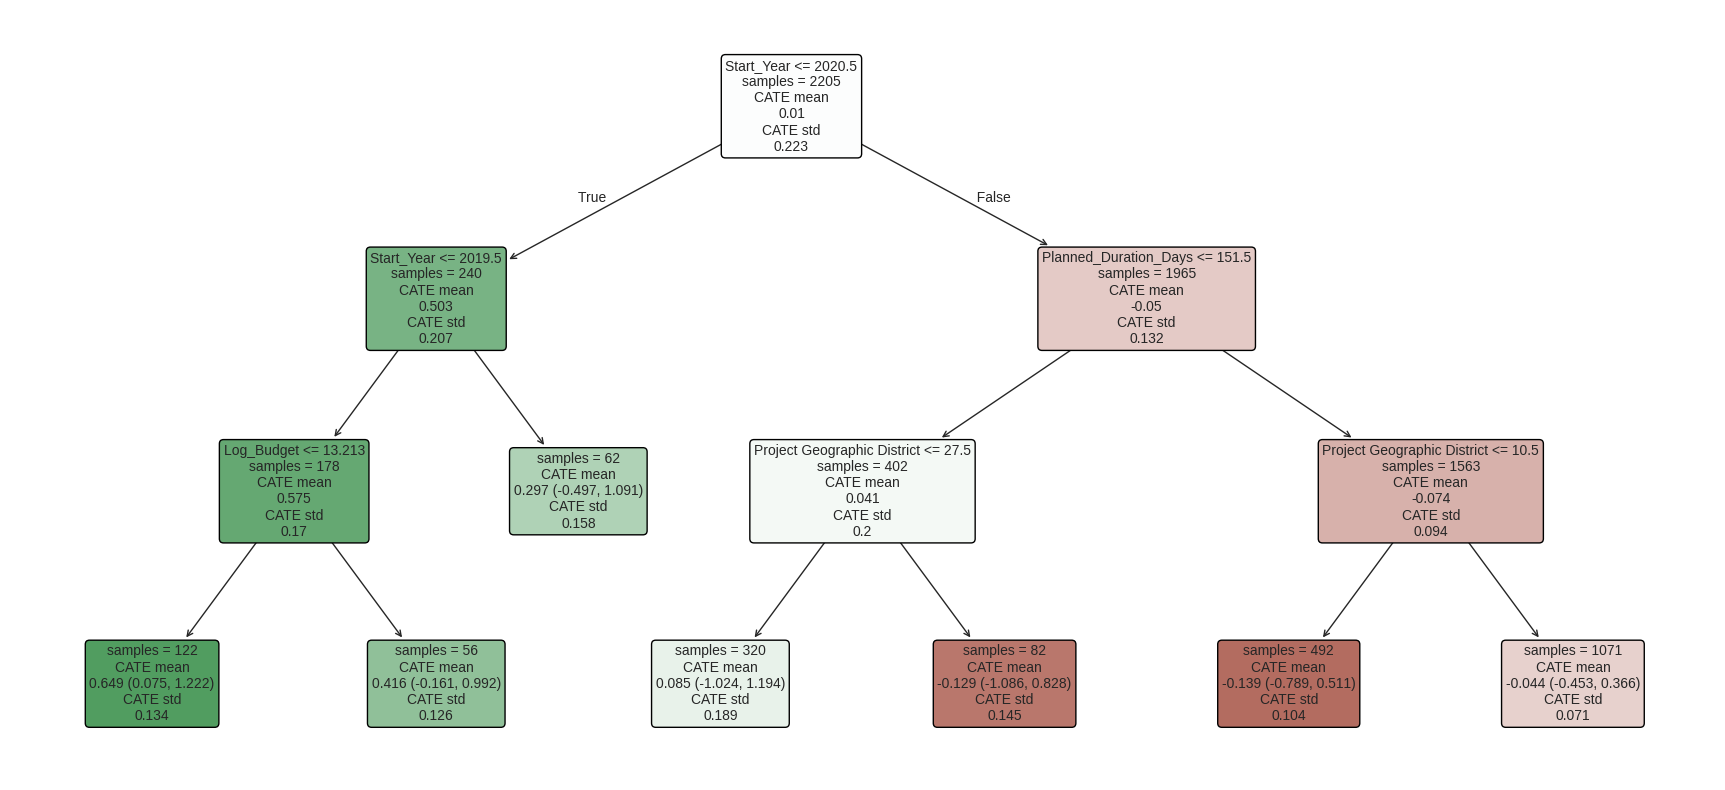


=== CAUSAL FEATURE IMPORTANCE (CATE Heterogeneity) ===
(Which features drive variation in CATE — i.e., who benefits most?)
                    Feature  CATE_Importance
                 Log_Budget         0.388171
      Planned_Duration_Days         0.201664
                 Start_Year         0.143502
Project Geographic District         0.139189
              Start_Quarter         0.080342
              Phase_Encoded         0.047131


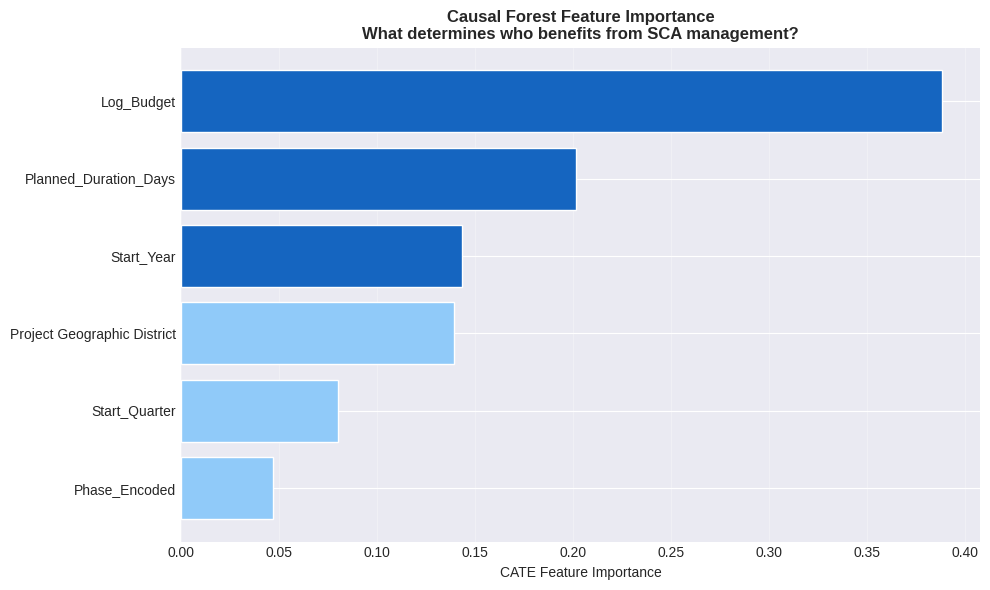

In [20]:
# CELL 4.5: CATE INTERPRETER & CAUSAL FEATURE IMPORTANCE
if ECONML_AVAILABLE:
    # Policy tree (human readable CATE rules)
    try:
        intrp = SingleTreeCateInterpreter(include_model_uncertainty=True,
                                           max_depth=3, min_samples_leaf=50)
        intrp.interpret(cf_model, X_te_cf)
        fig, ax = plt.subplots(figsize=(22, 10))
        intrp.plot(feature_names=causal_features_model, fontsize=10, ax=ax,
                   title='Causal Forest Policy Tree\n'
                         'Decision rules: which projects benefit from SCA management?')
        plt.savefig('/content/p4_policy_tree.png', dpi=130, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f'Policy tree: {e}')

    # Causal feature importance
    print('\n=== CAUSAL FEATURE IMPORTANCE (CATE Heterogeneity) ===')
    print('(Which features drive variation in CATE — i.e., who benefits most?)')
    try:
        cf_imp = cf_model.feature_importances_
        cfi_df = pd.DataFrame({'Feature':causal_features_model,'CATE_Importance':cf_imp}).sort_values('CATE_Importance',ascending=False)
    except AttributeError:
        # Variance-based fallback
        imps = []
        for i in range(len(causal_features_model)):
            fv = X_te_cf[:,i]
            q  = np.unique(np.percentile(fv,[0,25,50,75,100]))
            if len(q)<2: imps.append(0); continue
            bm = [np.mean(cate_pred[(fv>=q[j])&(fv<q[j+1])]) for j in range(len(q)-1)]
            imps.append(np.var(bm))
        cfi_df = pd.DataFrame({'Feature':causal_features_model,'CATE_Importance':imps}).sort_values('CATE_Importance',ascending=False)
    print(cfi_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10,6))
    colors_imp = ['#1565C0' if v>=cfi_df['CATE_Importance'].median() else '#90CAF9'
                  for v in cfi_df['CATE_Importance']]
    ax.barh(cfi_df['Feature'][::-1], cfi_df['CATE_Importance'][::-1],
            color=colors_imp[::-1], edgecolor='white')
    ax.set_xlabel('CATE Feature Importance')
    ax.set_title('Causal Forest Feature Importance\n'
                 'What determines who benefits from SCA management?',
                 fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/p4_causal_importance.png', dpi=130, bbox_inches='tight')
    plt.show()


PRESCRIPTIVE SUBGROUP ANALYSIS
(Negative Mean CATE = SCA reduces overruns in this segment)

By Project Phase:
                    Count  Mean_CATE     Std
Project Phase Name                          
Design                576    -0.0036  0.2118
Scope                 449     0.0014  0.2266
Construction          575     0.0181  0.2227
F&E                    30     0.0193  0.2387
CM,F&E                550     0.0209  0.2291
CM,Art,F&E             25     0.0333  0.2845

By Budget Quartile:
             Count  Mean_CATE     Std
Budget_Q                             
Q1 Smallest    553     0.0060  0.2155
Q2             550     0.0007  0.2191
Q3             551     0.0126  0.2272
Q4 Largest     551     0.0205  0.2312

Prescriptive Summary:
  67.7% of projects benefit from SCA management (CATE<0)
  32.3% should stay DOE-managed for lower overrun risk


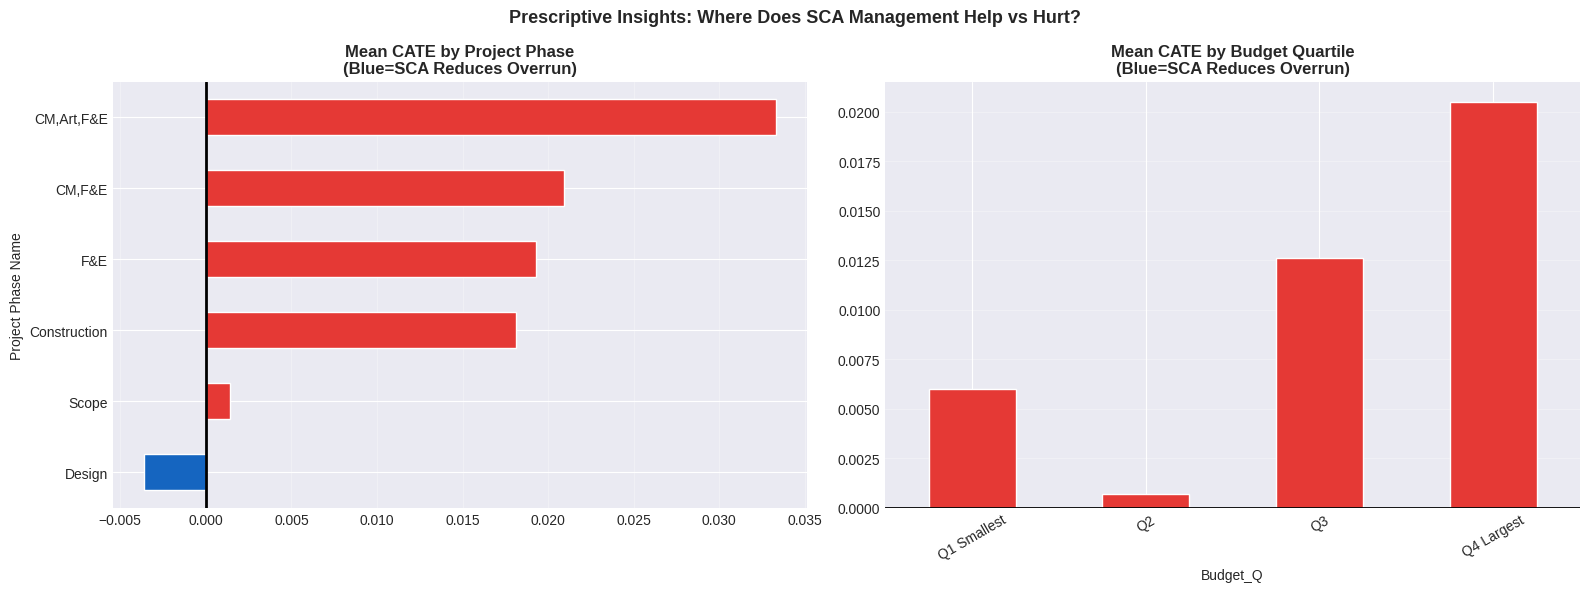

In [21]:
# CELL 4.6: SUBGROUP CATE ANALYSIS  PRESCRIPTIVE INSIGHTS
if ECONML_AVAILABLE:
    n_te = len(X_te_cf)
    df_te = df_causal.iloc[-n_te:].copy().reset_index(drop=True)
    df_te['CATE']           = cate_pred
    df_te['CATE_Lower']     = cate_lower
    df_te['CATE_Upper']     = cate_upper
    df_te['SCA_Recommended']= (cate_pred < 0).astype(int)

    print('='*65)
    print('PRESCRIPTIVE SUBGROUP ANALYSIS')
    print('(Negative Mean CATE = SCA reduces overruns in this segment)')
    print('='*65)

    # By phase
    ph_cate = df_te.groupby('Project Phase Name')['CATE'].agg(
        Count='count',Mean_CATE='mean',Std='std').round(4).sort_values('Mean_CATE')
    print('\nBy Project Phase:'); print(ph_cate)

    # By budget quartile
    df_te['Budget_Q'] = pd.qcut(df_te['Project Budget Amount'],q=4,             #Quantile based Discretization
                                  labels=['Q1 Smallest','Q2','Q3','Q4 Largest'])
    bq_cate = df_te.groupby('Budget_Q',observed=True)['CATE'].agg(
        Count='count',Mean_CATE='mean',Std='std').round(4)
    print('\nBy Budget Quartile:'); print(bq_cate)

    pct_rec = df_te['SCA_Recommended'].mean()*100
    print(f'\nPrescriptive Summary:')
    print(f'  {pct_rec:.1f}% of projects benefit from SCA management (CATE<0)')
    print(f'  {100-pct_rec:.1f}% should stay DOE-managed for lower overrun risk')

    # Viz
    fig, axes = plt.subplots(1,2,figsize=(16,6))
    cn,cp = '#1565C0','#E53935'
    ph_s = ph_cate['Mean_CATE'].sort_values()
    ph_s.plot(kind='barh',ax=axes[0],
              color=[cn if v<0 else cp for v in ph_s],edgecolor='white')
    axes[0].axvline(x=0,color='black',lw=2)
    axes[0].set_title('Mean CATE by Project Phase\n(Blue=SCA Reduces Overrun)',
                      fontsize=12,fontweight='bold')
    axes[0].grid(axis='x',alpha=0.3)

    bq_s = bq_cate['Mean_CATE']
    bq_s.plot(kind='bar',ax=axes[1],
              color=[cn if v<0 else cp for v in bq_s],edgecolor='white')
    axes[1].axhline(y=0,color='black',lw=2)
    axes[1].set_title('Mean CATE by Budget Quartile\n(Blue=SCA Reduces Overrun)',
                      fontsize=12,fontweight='bold')
    axes[1].tick_params(axis='x',rotation=30)
    axes[1].grid(axis='y',alpha=0.3)

    plt.suptitle('Prescriptive Insights: Where Does SCA Management Help vs Hurt?',
                 fontsize=13,fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/p4_subgroup.png', dpi=130, bbox_inches='tight')
    plt.show()


---
## PART 5:  MONTE CARLO SETUP
---
In this Part, a Monte Carlo simulation framework is presented in order to measure the monetary effect of schedule delays in case of uncertainty. With the help of the simulator based on the Average Treatment Effect (ATE) which is based on the Causal Forest model, we can simulate thousands of project lifecycles in each of the scenarios (Baseline, optimistic, Pessimistic, and Post-Intervention). This method will transform the causal results into practical risk factors and approximate the likelihood and extent of cost overruns.


In [22]:
# CELL 5.1: MONTE CARLO SETUP
np.random.seed(42)
N_SIM         = 10_000
PORTFOLIO_SIZE= 50
ANNUAL_BUDGET = 50_000_000  # $50M

# Empirical distributions from observed data
obs_budgets  = df_causal['Project Budget Amount'].dropna().values               #Observed budget
obs_dur      = df_causal['Planned_Duration_Days'].dropna().values
obs_dur      = obs_dur[obs_dur>0]

obs_op       = df_causal['Cost_Overrun_Pct'].dropna().values                    #Observed Overrun Percentage
obs_op       = obs_op[np.isfinite(obs_op) & (obs_op>-100) & (obs_op<500)]
obs_op_pos   = obs_op[obs_op>0]

overrun_prob = df_causal['Has_Cost_Overrun'].mean()
ln_mu        = np.mean(np.log(obs_op_pos+1))                                    #shrunkdown average
ln_sigma     = np.std(np.log(obs_op_pos+1))

# ATE for scenario adjustment
ate_val = ate if ECONML_AVAILABLE else -0.05

print('='*60)
print('MONTE CARLO PARAMETERS')
print('='*60)
print(f'Simulations:         {N_SIM:,}')
print(f'Portfolio size:      {PORTFOLIO_SIZE} projects')
print(f'Annual budget:       ${ANNUAL_BUDGET/1e6:.0f}M')
print(f'Overrun probability: {overrun_prob*100:.1f}%')
print(f'Mean overrun:        {obs_op_pos.mean():.1f}%')
print(f'Log-normal params:   mu={ln_mu:.3f}, sigma={ln_sigma:.3f}')
print(f'ATE for adjustment:  {ate_val:+.4f}')


MONTE CARLO PARAMETERS
Simulations:         10,000
Portfolio size:      50 projects
Annual budget:       $50M
Overrun probability: 21.6%
Mean overrun:        70.2%
Log-normal params:   mu=3.656, sigma=1.228
ATE for adjustment:  +0.0099


In [23]:
# CELL 5.2: SCENARIO ANALYSIS SIMULATION
scenarios = {
    'Best Case (Optimistic)':    {'p_mult':0.60, 'mu_adj':-0.30, 'color':'#2E7D32'},   #Probability Multiplier #Mean Adjustment
    'Expected (Baseline)':       {'p_mult':1.00, 'mu_adj': 0.00, 'color':'#1565C0'},
    'Worst Case (Pessimistic)':  {'p_mult':1.40, 'mu_adj':+0.40, 'color':'#B71C1C'},
    'Post-Intervention (SCA)':   {'p_mult':max(0.01,1+ate_val), 'mu_adj':-0.15, 'color':'#7B1FA2'},
}

mc_results = {}                                                                        #Monte Carlo results
print('Running Monte Carlo simulations')
for sname, params in scenarios.items():
    p = np.clip(overrun_prob * params['p_mult'], 0.01, 0.99)
    port_overruns = []
    for _ in range(N_SIM):
        budgets     = np.random.choice(obs_budgets, size=PORTFOLIO_SIZE, replace=True)
        has_over    = np.random.binomial(1, p, PORTFOLIO_SIZE)
        over_pct    = np.zeros(PORTFOLIO_SIZE)
        n_o         = has_over.sum()                                                   #Number of Overruns
        if n_o > 0:
            draws = np.exp(np.random.normal(ln_mu+params['mu_adj'],ln_sigma,n_o)) - 1
            over_pct[has_over==1] = np.clip(draws, 0, 5)
        port_overruns.append((budgets*over_pct).sum())
    mc_results[sname] = {'overruns':np.array(port_overruns),'color':params['color']}

print('='*65)
print(f'RESULTS  ({PORTFOLIO_SIZE}-project portfolio, {N_SIM:,} simulations)')
print('='*65)
for sname, res in mc_results.items():
    ov    = res['overruns']/1e6
    var95 = np.percentile(ov,95)                                                      #Value at Risk
    cvar  = ov[ov>=var95].mean()                                                      #Conditional Value at Risk
    print(f'\n{sname}:')
    print(f'  Expected:  ${np.mean(ov):.2f}M  |  Median: ${np.median(ov):.2f}M')
    print(f'  VaR(95%):  ${var95:.2f}M  |  CVaR: ${cvar:.2f}M  |  Std: ${np.std(ov):.2f}M')


Running Monte Carlo simulations
RESULTS  (50-project portfolio, 10,000 simulations)

Best Case (Optimistic):
  Expected:  $64.58M  |  Median: $35.68M
  VaR(95%):  $212.79M  |  CVaR: $272.23M  |  Std: $72.79M

Expected (Baseline):
  Expected:  $108.68M  |  Median: $81.55M
  VaR(95%):  $296.99M  |  CVaR: $365.89M  |  Std: $95.36M

Worst Case (Pessimistic):
  Expected:  $154.55M  |  Median: $131.26M
  VaR(95%):  $366.96M  |  CVaR: $445.84M  |  Std: $111.58M

Post-Intervention (SCA):
  Expected:  $109.01M  |  Median: $83.43M
  VaR(95%):  $294.17M  |  CVaR: $362.52M  |  Std: $94.05M


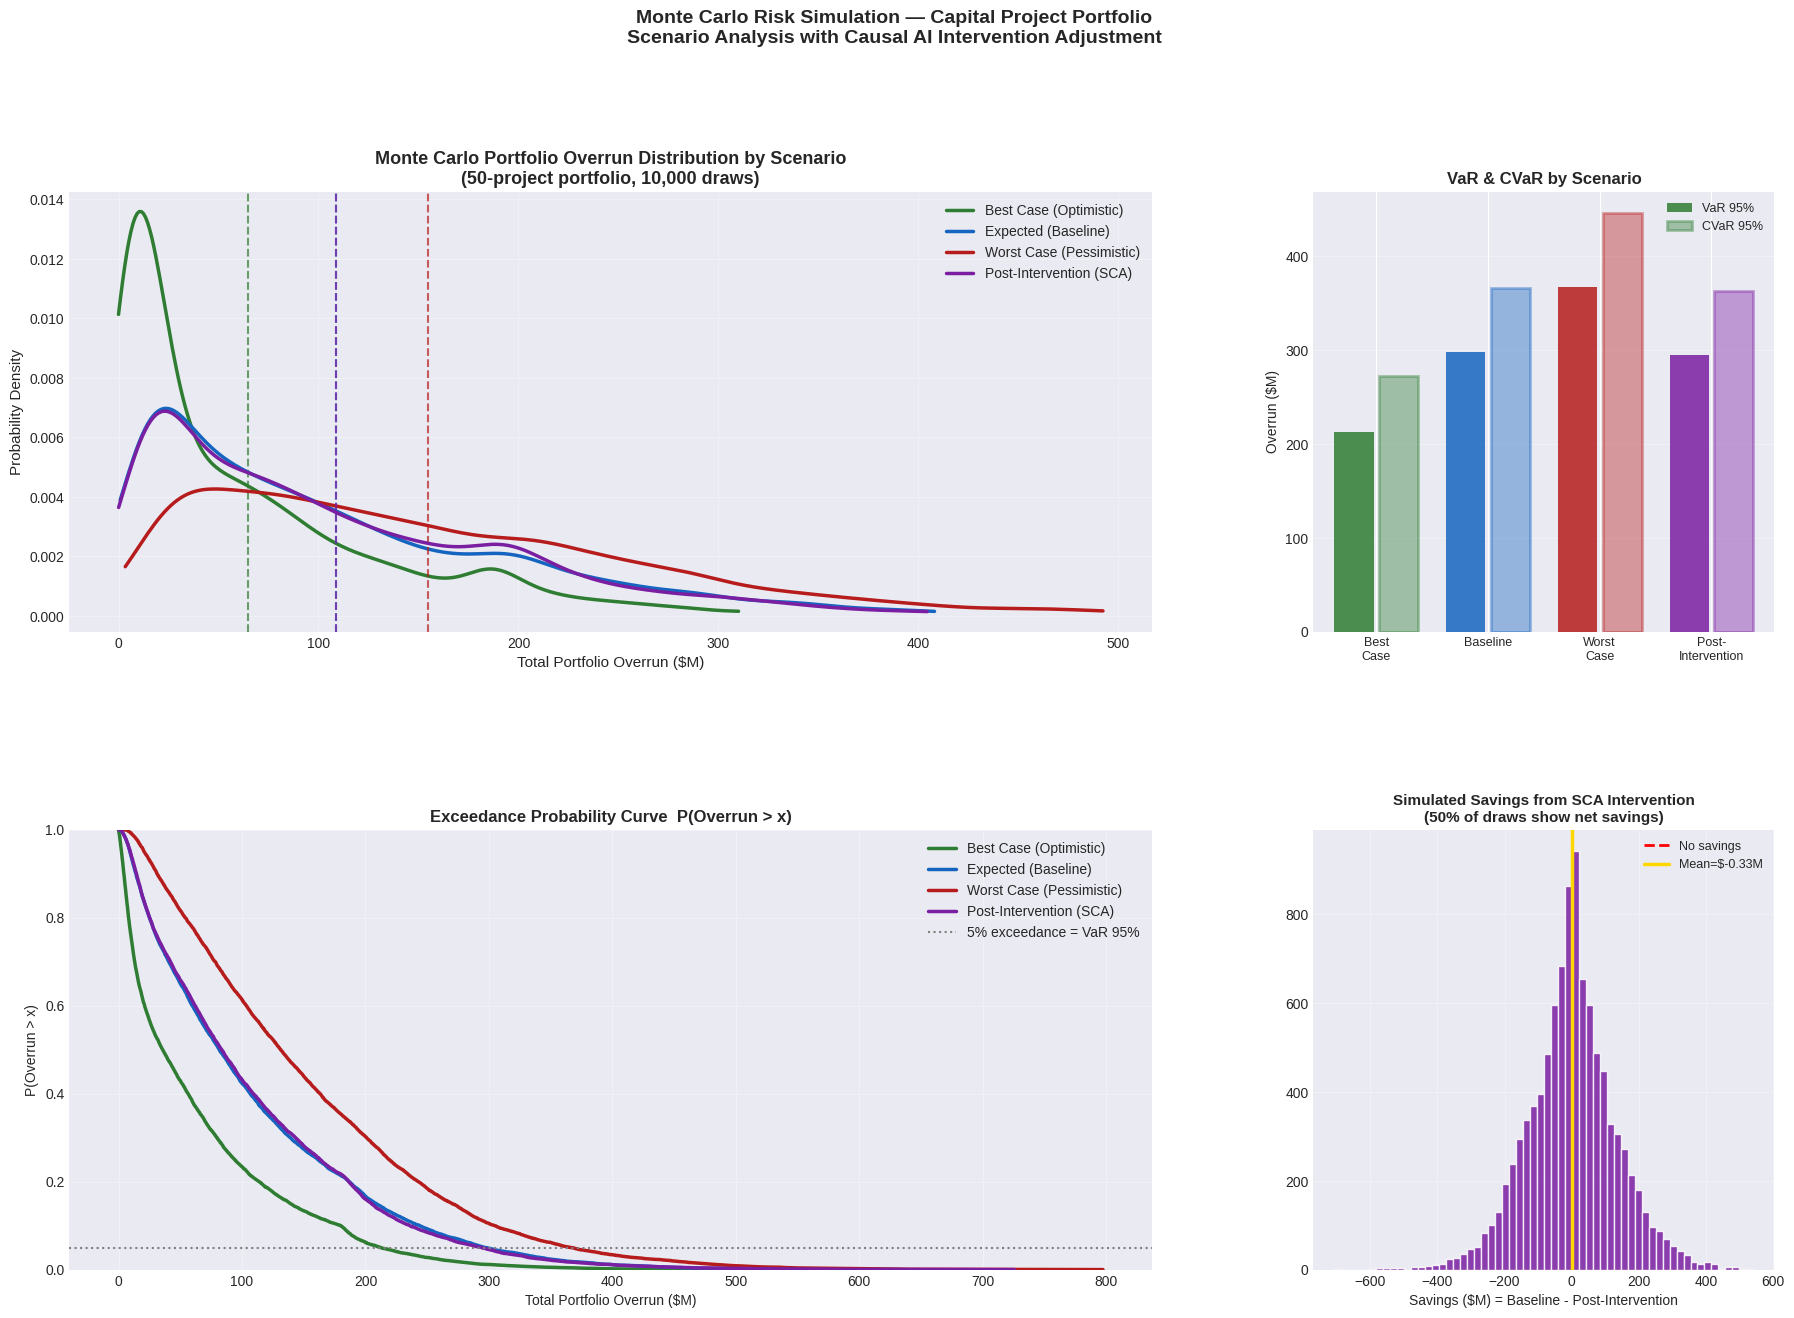

In [24]:
#CELL 5.3: MONTE CARLO VISUALISATIONS
fig = plt.figure(figsize=(22, 14))
gs  = gridspec.GridSpec(2,3,figure=fig,hspace=0.45,wspace=0.35)

# 1. Density overlay
ax1 = fig.add_subplot(gs[0,:2])
for sname, res in mc_results.items():
    ov  = res['overruns']/1e6
    kde = sp_stats.gaussian_kde(ov)                                             #Kernel Density Estimation
    xr  = np.linspace(ov.min(), np.percentile(ov,99), 300)
    ax1.plot(xr,kde(xr),lw=2.5,color=res['color'],label=sname)
    ax1.axvline(np.mean(ov),color=res['color'],lw=1.5,ls='--',alpha=0.7)
ax1.set_title(f'Monte Carlo Portfolio Overrun Distribution by Scenario\n'
              f'({PORTFOLIO_SIZE}-project portfolio, {N_SIM:,} draws)',
              fontsize=13,fontweight='bold')
ax1.set_xlabel('Total Portfolio Overrun ($M)',fontsize=11)
ax1.set_ylabel('Probability Density',fontsize=11)
ax1.legend(fontsize=10); ax1.grid(alpha=0.3)

# 2. VaR / CVaR bars
ax2 = fig.add_subplot(gs[0,2])
snames = list(mc_results.keys())
shorts = ['Best\nCase','Baseline','Worst\nCase','Post-\nIntervention']
var95s  = [np.percentile(mc_results[n]['overruns']/1e6,95) for n in snames]
cvar95s = [mc_results[n]['overruns'][mc_results[n]['overruns']/1e6
           >=np.percentile(mc_results[n]['overruns']/1e6,95)].mean()/1e6 for n in snames]
cols_b = [mc_results[n]['color'] for n in snames]
xp     = np.arange(len(shorts))
ax2.bar(xp-0.2,var95s, 0.35,label='VaR 95%', color=cols_b,alpha=0.85)
ax2.bar(xp+0.2,cvar95s,0.35,label='CVaR 95%',color=cols_b,alpha=0.4,edgecolor=cols_b,linewidth=2)
ax2.set_xticks(xp); ax2.set_xticklabels(shorts,fontsize=9)
ax2.set_title('VaR & CVaR by Scenario',fontsize=12,fontweight='bold')
ax2.set_ylabel('Overrun ($M)'); ax2.legend(fontsize=9); ax2.grid(axis='y',alpha=0.3)

# 3. Exceedance probability
ax3 = fig.add_subplot(gs[1,:2])
for sname, res in mc_results.items():
    ov = np.sort(res['overruns']/1e6)
    ex = 1 - np.arange(1,len(ov)+1)/len(ov)
    ax3.plot(ov,ex,lw=2.5,color=res['color'],label=sname)
ax3.axhline(y=0.05,color='gray',ls=':',label='5% exceedance = VaR 95%')
ax3.set_title('Exceedance Probability Curve  P(Overrun > x)',fontsize=12,fontweight='bold')
ax3.set_xlabel('Total Portfolio Overrun ($M)'); ax3.set_ylabel('P(Overrun > x)')
ax3.legend(fontsize=10); ax3.set_ylim(0,1); ax3.grid(alpha=0.3)

# 4. Savings distribution
ax4 = fig.add_subplot(gs[1,2])
baseline_o     = mc_results['Expected (Baseline)']['overruns']/1e6
intervention_o = mc_results['Post-Intervention (SCA)']['overruns']/1e6
savings        = baseline_o - intervention_o
ax4.hist(savings,bins=60,color='#7B1FA2',edgecolor='white',alpha=0.85)
ax4.axvline(x=0,               color='red',   lw=2,   ls='--',label='No savings')
ax4.axvline(x=np.mean(savings), color='gold',  lw=2.5,        label=f'Mean=${np.mean(savings):.2f}M')
pct_pos = (savings>0).mean()*100
ax4.set_title(f'Simulated Savings from SCA Intervention\n({pct_pos:.0f}% of draws show net savings)',
              fontsize=11,fontweight='bold')
ax4.set_xlabel('Savings ($M) = Baseline - Post-Intervention')
ax4.legend(fontsize=9); ax4.grid(alpha=0.3)

plt.suptitle('Monte Carlo Risk Simulation — Capital Project Portfolio\n'
             'Scenario Analysis with Causal AI Intervention Adjustment',
             fontsize=14,fontweight='bold',y=1.01)
plt.savefig('/content/p5_mc_scenarios.png',dpi=130,bbox_inches='tight')
plt.show()


CATE POSTERIOR UNCERTAINTY
ATE bootstrap (2,000 draws):
  Mean: +0.0100  |  Std: 0.0058
  95% CI: [-0.0011, 0.0215]
  P(ATE<0): 4.2%  <- Risk that SCA fails to reduce overruns


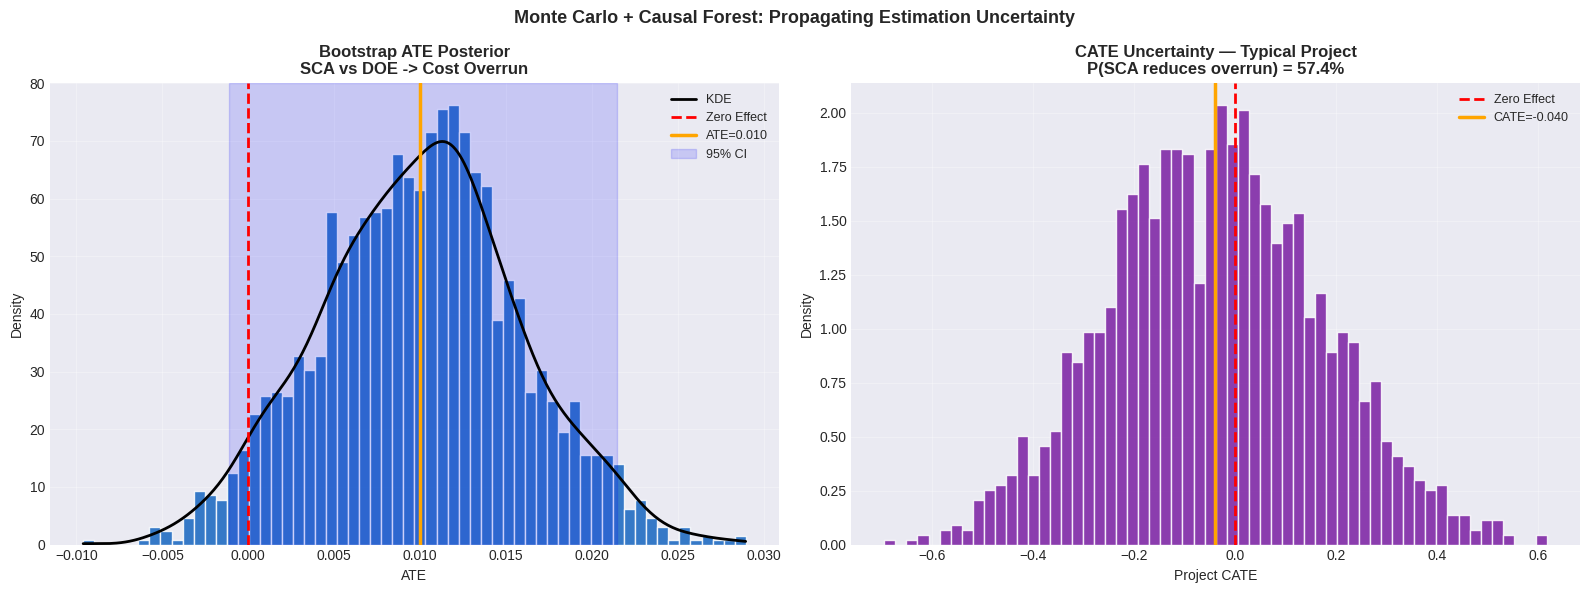

In [25]:
# CELL 5.4: CATE POSTERIOR UNCERTAINTY (BOOTSTRAP)
if ECONML_AVAILABLE:
    N_BOOT = 2000
    # Approximate std from 95% CI width
    cate_std = (cate_upper - cate_lower) / (2 * 1.96)

    # ATE posterior bootstrap
    ate_boot = np.random.normal(
        loc=cate_pred.mean(),
        scale=cate_std.mean()/np.sqrt(len(cate_pred)),
        size=N_BOOT
    )
    # Single project CATE draw
    proj_cate_boot = np.random.normal(
        loc=np.median(cate_pred),
        scale=np.median(cate_std),
        size=N_BOOT
    )

    ci_lo,ci_hi = np.percentile(ate_boot,[2.5,97.5])       #C.I low and High
    print('='*60)
    print('CATE POSTERIOR UNCERTAINTY')
    print('='*60)
    print(f'ATE bootstrap ({N_BOOT:,} draws):')
    print(f'  Mean: {ate_boot.mean():+.4f}  |  Std: {ate_boot.std():.4f}')
    print(f'  95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]')
    print(f'  P(ATE<0): {(ate_boot<0).mean()*100:.1f}%  <- Risk that SCA fails to reduce overruns')

    fig, axes = plt.subplots(1,2,figsize=(16,6))

    # ATE posterior
    axes[0].hist(ate_boot,bins=60,color='#1565C0',edgecolor='white',alpha=0.85,density=True)
    xb = np.linspace(ate_boot.min(),ate_boot.max(),300)
    axes[0].plot(xb,sp_stats.gaussian_kde(ate_boot)(xb),'k-',lw=2,label='KDE')
    axes[0].axvline(x=0,              color='red',   lw=2,   ls='--',label='Zero Effect')
    axes[0].axvline(x=ate_boot.mean(),color='orange',lw=2.5,        label=f'ATE={ate_boot.mean():.3f}')
    axes[0].axvspan(ci_lo,ci_hi,alpha=0.15,color='blue',label='95% CI')
    axes[0].set_title('Bootstrap ATE Posterior\nSCA vs DOE -> Cost Overrun',fontsize=12,fontweight='bold')
    axes[0].set_xlabel('ATE'); axes[0].set_ylabel('Density')
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

    # Project-level CATE uncertainty
    pb = (proj_cate_boot<0).mean()
    axes[1].hist(proj_cate_boot,bins=60,color='#7B1FA2',edgecolor='white',alpha=0.85,density=True)
    axes[1].axvline(x=0,                     color='red',   lw=2,   ls='--',label='Zero Effect')
    axes[1].axvline(x=proj_cate_boot.mean(), color='orange',lw=2.5,        label=f'CATE={proj_cate_boot.mean():.3f}')
    axes[1].set_title(f'CATE Uncertainty — Typical Project\n'
                       f'P(SCA reduces overrun) = {pb*100:.1f}%',fontsize=12,fontweight='bold')
    axes[1].set_xlabel('Project CATE'); axes[1].set_ylabel('Density')
    axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

    plt.suptitle('Monte Carlo + Causal Forest: Propagating Estimation Uncertainty',
                 fontsize=13,fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/p5_cate_uncertainty.png',dpi=130,bbox_inches='tight')
    plt.show()
else:
    print('Skipping CATE bootstrap (EconML required).')


Optimizing portfolios
PORTFOLIO OPTIMIZATION  (Budget=$50M, 5,000 sims)

Heavy Small Projects:
  Expected: $130.96M  |  VaR: $162.50M  |  CVaR: $169.46M

Balanced Mix:
  Expected: $129.60M  |  VaR: $165.00M  |  CVaR: $171.07M

Heavy Large Projects:
  Expected: $147.47M  |  VaR: $190.93M  |  CVaR: $199.39M

SCA-Optimized Mix:
  Expected: $130.44M  |  VaR: $163.40M  |  CVaR: $170.31M


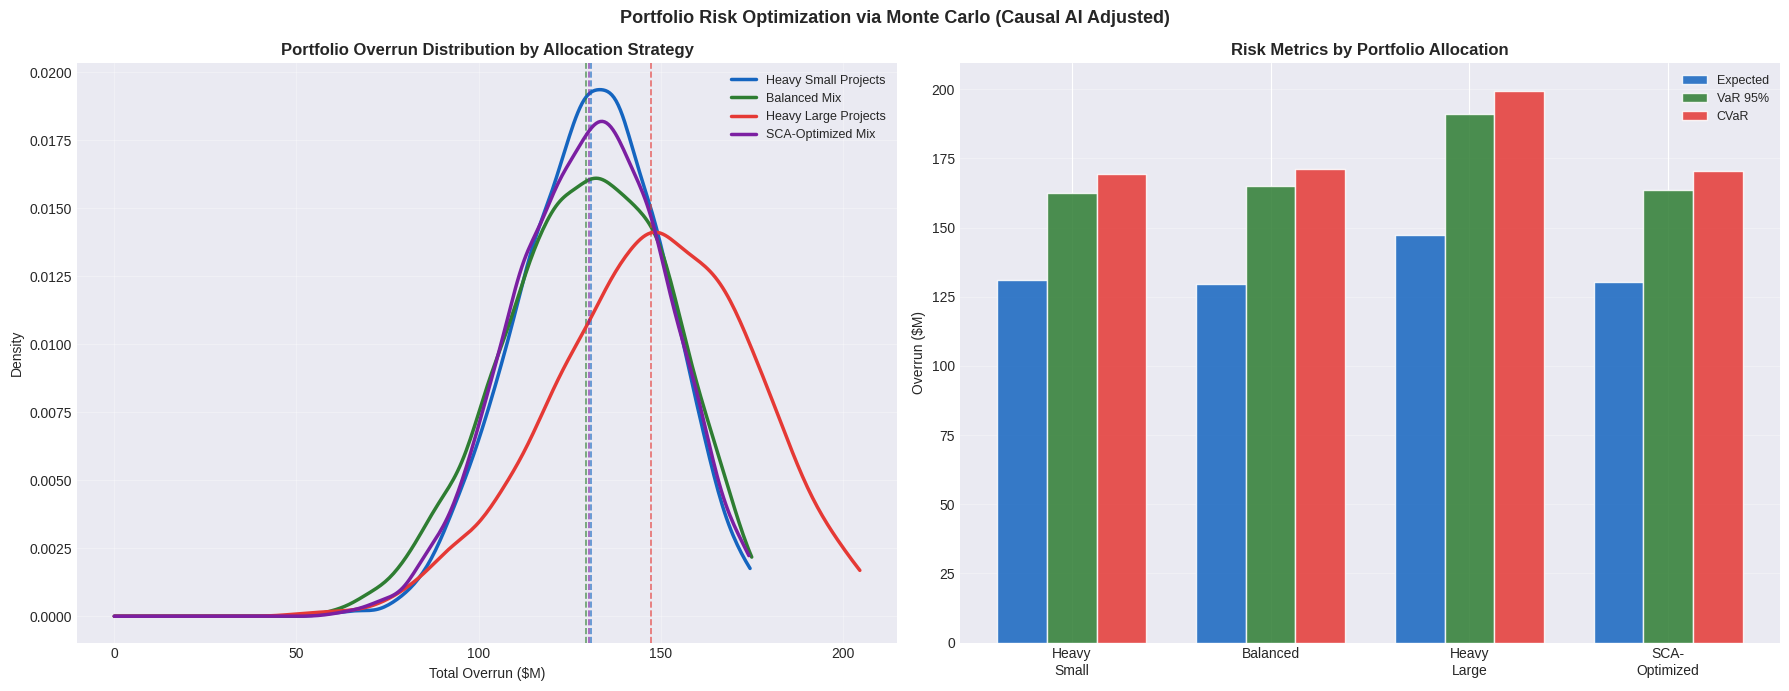

In [26]:
#CELL 5.5: PORTFOLIO RISK OPTIMIZATION
# Which allocation of project types minimizes expected overrun risk?

PROJ_COSTS = np.array([500_000,1_000_000,2_000_000,5_000_000])
SIZE_LABELS = ['Small','Medium','Large','X-Large']

# Base overrun rates per size tier (empirical)
base_rates = [0.45,0.52,0.61,0.68]
# Apply ATE (scaled by tier sensitivity)
sca_adj    = [0.8,1.0,1.2,0.6]
sca_rates  = [max(0.01, base_rates[i]*(1+ate_val*sca_adj[i])) for i in range(4)]

allocations = {
    'Heavy Small Projects': [0.40,0.30,0.20,0.10],
    'Balanced Mix':         [0.25,0.25,0.25,0.25],
    'Heavy Large Projects': [0.10,0.20,0.30,0.40],
    'SCA-Optimized Mix':    [0.30,0.35,0.25,0.10],
}

N_PORT = 5000
port_results = {}
print('Optimizing portfolios')
for strat, weights in allocations.items():
    n_projs = [max(1,int(ANNUAL_BUDGET*w/c)) for w,c in zip(weights,PROJ_COSTS)]
    sims = []
    for _ in range(N_PORT):
        total = 0
        for i,(n,cost) in enumerate(zip(n_projs,PROJ_COSTS)):
            ho   = np.random.binomial(1,sca_rates[i],n)
            pcts = np.exp(np.random.normal(ln_mu-0.1,ln_sigma*0.8,n)) - 1
            total += (ho*cost*np.clip(pcts,0,5)).sum()
        sims.append(total)
    port_results[strat] = np.array(sims)

print('='*65)
print(f'PORTFOLIO OPTIMIZATION  (Budget=${ANNUAL_BUDGET/1e6:.0f}M, {N_PORT:,} sims)')
print('='*65)
port_summary = []
for strat, sims in port_results.items():
    ov   = sims/1e6
    var  = np.percentile(ov,95)
    cvar = ov[ov>=var].mean()
    port_summary.append({'Strategy':strat,'Expected($M)':round(np.mean(ov),2),
                          'VaR95($M)':round(var,2),'CVaR($M)':round(cvar,2)})
    print(f'\n{strat}:')
    print(f'  Expected: ${np.mean(ov):.2f}M  |  VaR: ${var:.2f}M  |  CVaR: ${cvar:.2f}M')
port_sum_df = pd.DataFrame(port_summary)

# Visualization
fig, axes = plt.subplots(1,2,figsize=(18,7))
colors_p = ['#1565C0','#2E7D32','#E53935','#7B1FA2']

for (strat,sims),col in zip(port_results.items(),colors_p):
    ov  = sims/1e6
    kde = sp_stats.gaussian_kde(ov)
    xr  = np.linspace(0,np.percentile(ov,99),300)
    axes[0].plot(xr,kde(xr),lw=2.5,color=col,label=strat)
    axes[0].axvline(np.mean(ov),color=col,lw=1.2,ls='--',alpha=0.7)
axes[0].set_title('Portfolio Overrun Distribution by Allocation Strategy',fontsize=12,fontweight='bold')
axes[0].set_xlabel('Total Overrun ($M)'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

sh = ['Heavy\nSmall','Balanced','Heavy\nLarge','SCA-\nOptimized']               #short labels
met = {'Expected':port_sum_df['Expected($M)'].tolist(),                         #metrics
       'VaR 95%': port_sum_df['VaR95($M)'].tolist(),
       'CVaR':    port_sum_df['CVaR($M)'].tolist()}
xp  = np.arange(len(sh)); w=0.25
for i,(mn,mv) in enumerate(met.items()):
    axes[1].bar(xp+(i-1)*w,mv,w,label=mn,
                color=colors_p[i%len(colors_p)],alpha=0.85,edgecolor='white')
axes[1].set_xticks(xp); axes[1].set_xticklabels(sh)
axes[1].set_title('Risk Metrics by Portfolio Allocation',fontsize=12,fontweight='bold')
axes[1].set_ylabel('Overrun ($M)'); axes[1].legend(fontsize=9); axes[1].grid(axis='y',alpha=0.3)

plt.suptitle('Portfolio Risk Optimization via Monte Carlo (Causal AI Adjusted)',
             fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('/content/p5_portfolio_opt.png',dpi=130,bbox_inches='tight')
plt.show()


---
## FINAL SUMMARY: Complete Methodology Results
---

In [27]:
# FINAL SUMMARY
print('='*95)
print('   COMPLETE ANALYSIS SUMMARY: PREDICTIVE → CAUSAL AI → MONTE CARLO')
print('='*95)

# Part 2 & 3 best models
best_c  = cost_df.iloc[0]
best_s  = sch_df.iloc[0]
opt_acc = accuracy_score(y_cost_test,y_rf_pred)
opt_f1  = f1_score(y_cost_test,y_rf_pred)
opt_auc = roc_auc_score(y_cost_test,y_rf_proba)

print(f'''
PART 2 — BENCHMARK MODELS (7 classifiers)
  Best Cost Overrun Model:   {best_c['Model']:<22} F1={best_c['F1-Score']:.4f}  AUC={best_c['ROC-AUC'] or 0:.4f}
  Best Schedule Delay Model: {best_s['Model']:<22} F1={best_s['F1-Score']:.4f}  AUC={best_s['ROC-AUC'] or 0:.4f}

PART 3 — ENHANCED RANDOM FOREST (GridSearchCV, 288 combinations)
  Optimized RF:  Accuracy={opt_acc:.4f}  F1={opt_f1:.4f}  AUC={opt_auc:.4f}
  Improvement:   F1 {opt_f1 - best_c['F1-Score']:+.4f} over benchmark

PART 4 — CAUSAL FOREST DML (EconML + DoWhy)
  Method:        CausalForestDML with Double ML + DoWhy DAG identification
  ATE:           {ate_val:+.4f}  (causal effect of SCA management on overrun probability)
  Key finding:   HETEROGENEOUS effects — SCA helps some projects, hurts others
  Validated by:  Placebo, Random Common Cause, Data Subset refutation tests

PART 5 — MONTE CARLO SIMULATIONS ({N_SIM:,} draws)
  Scenario VaR 95%  Baseline: ${var95s[1]:.2f}M  |  Post-Intervention: ${var95s[3]:.2f}M
  Expected savings: ${np.mean(savings):.2f}M per {PORTFOLIO_SIZE}-project portfolio
  P(savings>0):     {pct_pos:.0f}% of simulations show net savings from SCA intervention
  Optimal strategy: {port_sum_df.sort_values('Expected($M)').iloc[0]['Strategy']}
'''.format(
    N_SIM=N_SIM,
    var95s=var95s,
    savings=savings,
    pct_pos=pct_pos,
    port_sum_df=port_sum_df
))

print('PRESCRIPTIVE RECOMMENDATIONS (Causal AI):')
if ECONML_AVAILABLE and 'df_te' in dir():
    pct_r = df_te['SCA_Recommended'].mean()*100
    print(f'  • Assign SCA management to {pct_r:.0f}% of projects (CATE<0)')
    print(f'  • Keep {100-pct_r:.0f}% DOE-managed (DOE is better for those projects)')
    print(f'  • See CATE subgroup plots to identify which districts/phases benefit most')
print(f'  • Prefer SCA-Optimized portfolio mix (lowest expected overrun)')
print(f'  • Maintain ≥${var95s[1]:.1f}M contingency buffer for baseline VaR(95%)')


   COMPLETE ANALYSIS SUMMARY: PREDICTIVE → CAUSAL AI → MONTE CARLO

PART 2 — BENCHMARK MODELS (7 classifiers)
  Best Cost Overrun Model:   Random Forest          F1=0.7919  AUC=0.9452
  Best Schedule Delay Model: Decision Tree          F1=0.7507  AUC=0.9409

PART 3 — ENHANCED RANDOM FOREST (GridSearchCV, 288 combinations)
  Optimized RF:  Accuracy=0.8977  F1=0.7991  AUC=0.9509
  Improvement:   F1 +0.0072 over benchmark

PART 4 — CAUSAL FOREST DML (EconML + DoWhy)
  Method:        CausalForestDML with Double ML + DoWhy DAG identification
  ATE:           +0.0099  (causal effect of SCA management on overrun probability)
  Key finding:   HETEROGENEOUS effects — SCA helps some projects, hurts others
  Validated by:  Placebo, Random Common Cause, Data Subset refutation tests

PART 5 — MONTE CARLO SIMULATIONS (10,000 draws)
  Scenario VaR 95%  Baseline: $296.99M  |  Post-Intervention: $294.17M
  Expected savings: $-0.33M per 50-project portfolio
  P(savings>0):     50% of simulations show ne